# Compiler Aware Differentiable Quantum Architecture Search (QuantumDARTS)

# QuantumDARTS for Max-Cut (Macro Search and Micro Search)

Reproducing the Max-Cut experiments from *QuantumDARTS: Differentiable Quantum Architecture Search for Variational Quantum Algorithms* (ICML 2023) using macro-search with Gumbel-Softmax. We will adhere to the paper's algorithm (forward/backward, notation, and gate set)

## Macro Search for Max-Cut
- Problem setup: graph instances, Max-Cut Hamiltonian, CVaR metric (top 20%)
- Algorithm (macro-search with Gumbel-Softmax): forward/backward equations
- Implementation scaffolding: gate set, architecture params $\alpha_{ij}$, rotation params $\theta$, circuit sampler, loss
- Training loop: alternating updates for $\theta$ and $\alpha$, temperature schedule
- Logging/visualization: CVaR vs. epochs, gate/depth stats, circuit viz
- Baselines and sanity checks: classical Max-Cut optimum, fixed QAOA-style ansatz


In [ ]:
import os
import math
import json
import random
import itertools
from dataclasses import dataclass
from typing import List, Tuple, Dict, Callable, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import networkx as nx
from scipy.optimize import brute
from tqdm import tqdm
import matplotlib.pyplot as plt

# Prefer GPU if available; macro-search in paper is full-amplitude sim.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)



Using device: cpu


## Problem setup: Max-Cut and evaluation
- Graphs: unweighted, 8–10 nodes to mirror the paper; store adjacency for reuse.
- Hamiltonian: standard Max-Cut cost $$H = \frac{1}{2} \sum_{(u,v)\in E} (I - Z_u Z_v)$$
- Objective: minimize expectation $\langle H \rangle$ over the PQC output state.
- Metric: CVaR over measurement outcomes (top 20% cut values) as reported.
- Classical optimum: compute via exact solver for benchmarking (small graphs).
- Shots: start with statevector expectation for speed, then validate with finite shots.


## Algorithm (macro-search with Gumbel-Softmax)
- Gate set $\mathcal{G}$: candidate operations (e.g., `Rx`, `Ry`, `Rz`, `CNOT/CZ`).
- Architecture weights $alpha_{ij}$: logits per layer `i` and gate choice `j`.
- Sampling (forward): $y_{ij} = \mathrm{softmax}((\alpha_{ij} + g_{ij}) / \tau)$, then pick argmax gate for unitarity (one-hot in forward pass).
- Backprop (architecture): gradients flow through the softmax relaxation w.r.t. $\alpha$; temperature $\tau$ annealed.
- Rotation parameters $\theta$: updated with standard optimizer on the PQC expectation.
- Alternating updates: (1) sample circuit with current $\alpha$, update $\theta$; (2) update $\alpha$ given loss; repeat until convergence.
- Loss: expectation of Max-Cut Hamiltonian (or CVaR-adjusted expectation) computed from the sampled circuit.
- Keep the exact math consistent with the paper’s notation when implementing (no mixing of gate-set $\mathcal{G}$ and Gumbel $g$).


In [ ]:
# ============================================================================
# 1. Gate Set and Unitary Matrix Representations
# ============================================================================

def pauli_x():
    """Pauli-X gate (NOT gate)"""
    return torch.tensor([[0., 1.], [1., 0.]], dtype=torch.complex64, device=DEVICE)

def pauli_y():
    """Pauli-Y gate"""
    return torch.tensor([[0., -1j], [1j, 0.]], dtype=torch.complex64, device=DEVICE)

def pauli_z():
    """Pauli-Z gate"""
    return torch.tensor([[1., 0.], [0., -1.]], dtype=torch.complex64, device=DEVICE)

def hadamard():
    """Hadamard gate"""
    return (1/np.sqrt(2)) * torch.tensor([[1., 1.], [1., -1.]], dtype=torch.complex64, device=DEVICE)

def identity_1q():
    """Single-qubit identity"""
    return torch.eye(2, dtype=torch.complex64, device=DEVICE)

def rotation_x(theta):
    """Rotation around X-axis: Rx(θ) = exp(-iθX/2)"""
    return torch.cos(theta/2) * identity_1q() - 1j * torch.sin(theta/2) * pauli_x()

def rotation_y(theta):
    """Rotation around Y-axis: Ry(θ) = exp(-iθY/2)"""
    return torch.cos(theta/2) * identity_1q() - 1j * torch.sin(theta/2) * pauli_y()

def rotation_z(theta):
    """Rotation around Z-axis: Rz(θ) = exp(-iθZ/2)"""
    return torch.cos(theta/2) * identity_1q() - 1j * torch.sin(theta/2) * pauli_z()

def cnot():
    """CNOT gate (control-target)"""
    return torch.tensor([
        [1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 0., 1.],
        [0., 0., 1., 0.]
    ], dtype=torch.complex64, device=DEVICE).reshape(2, 2, 2, 2)

def cz():
    """CZ gate (control-Z)"""
    return torch.tensor([
        [1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., -1.]
    ], dtype=torch.complex64, device=DEVICE).reshape(2, 2, 2, 2)

def apply_1q_gate(gate_1q, qubit_idx, n_qubits):
    """
    Apply single-qubit gate to specified qubit in n-qubit system.
    Returns 2^n x 2^n unitary matrix.
    """
    # Start with identity
    U = torch.eye(2**n_qubits, dtype=torch.complex64, device=DEVICE)
    
    # Apply gate to specified qubit
    for i in range(2**n_qubits):
        for j in range(2**n_qubits):
            # Check if bit patterns match except at qubit_idx
            i_bits = [(i >> k) & 1 for k in range(n_qubits)]
            j_bits = [(j >> k) & 1 for k in range(n_qubits)]
            
            if all(i_bits[k] == j_bits[k] for k in range(n_qubits) if k != qubit_idx):
                U[i, j] = gate_1q[i_bits[qubit_idx], j_bits[qubit_idx]]
    
    return U

def apply_2q_gate(gate_2q, control_idx, target_idx, n_qubits):
    """
    Apply two-qubit gate (CNOT/CZ) to specified qubits.
    gate_2q is 2x2x2x2 tensor.
    Returns 2^n x 2^n unitary matrix.
    """
    U = torch.zeros(2**n_qubits, 2**n_qubits, dtype=torch.complex64, device=DEVICE)
    
    for i in range(2**n_qubits):
        for j in range(2**n_qubits):
            i_bits = [(i >> k) & 1 for k in range(n_qubits)]
            j_bits = [(j >> k) & 1 for k in range(n_qubits)]
            
            # Check if bits match except at control and target
            if all(i_bits[k] == j_bits[k] for k in range(n_qubits) if k not in [control_idx, target_idx]):
                U[i, j] = gate_2q[i_bits[control_idx], i_bits[target_idx], j_bits[control_idx], j_bits[target_idx]]
    
    return U

def rzryrz(theta_0, theta_1, theta_2):
    """
    Composite gate RzRyRz: Rz(θ₂) * Ry(θ₁) * Rz(θ₀)
    As per paper Appendix C, this can express any single-qubit gate.
    """
    # Apply in sequence: Rz(θ₀) first, then Ry(θ₁), then Rz(θ₂)
    Rz0 = rotation_z(theta_0)
    Ry1 = rotation_y(theta_1)
    Rz2 = rotation_z(theta_2)
    # Matrix multiplication: Rz2 * Ry1 * Rz0
    return torch.matmul(Rz2, torch.matmul(Ry1, Rz0))

class GateSet:
    """
    Manages candidate gate set G = {RzRyRz, I, CNOT}
    As per paper experimental setup and Appendix C.
    """
    def __init__(self, n_qubits, include_entangling=True):
        self.n_qubits = n_qubits
        self.gate_names = []
        
        # Gate set per paper: {RzRyRz, I, CNOT}
        # RzRyRz is a composite gate (3 parameters: θ₀, θ₁, θ₂)
        self.gate_names = ['I', 'RzRyRz']
        
        if include_entangling:
            # Two-qubit gates: CNOT only (as per paper)
            # For each qubit pair (i, j) where i != j, we add CNOT(i->j)
            for i in range(n_qubits):
                for j in range(n_qubits):
                    if i != j:
                        self.gate_names.append(f'CNOT_{i}_{j}')
        
        self.K = len(self.gate_names)
        print(f"Gate set G = {{RzRyRz, I, CNOT}} initialized with {self.K} candidate gates for {n_qubits} qubits")
    
    def get_unitary(self, gate_name, qubit_idx, theta=None, n_qubits=None):
        """
        Get unitary matrix for a gate.
        For RzRyRz, theta should be a tuple/list of (theta_0, theta_1, theta_2)
        For 2-qubit gates, gate_name should be like 'CNOT_0_1'
        """
        if n_qubits is None:
            n_qubits = self.n_qubits
            
        if gate_name == 'I':
            return apply_1q_gate(identity_1q(), qubit_idx, n_qubits)
        elif gate_name == 'RzRyRz':
            if theta is None:
                raise ValueError("RzRyRz requires theta parameter (tuple of 3 angles)")
            if isinstance(theta, (list, tuple)) and len(theta) == 3:
                theta_0, theta_1, theta_2 = theta[0], theta[1], theta[2]
            elif hasattr(theta, '__len__') and len(theta) == 3:
                theta_0, theta_1, theta_2 = theta[0], theta[1], theta[2]
            else:
                # If single value, use it for all three (fallback)
                theta_0 = theta_1 = theta_2 = theta
            rzryrz_gate = rzryrz(theta_0, theta_1, theta_2)
            return apply_1q_gate(rzryrz_gate, qubit_idx, n_qubits)
        elif gate_name.startswith('CNOT_'):
            parts = gate_name.split('_')
            control = int(parts[1])
            target = int(parts[2])
            return apply_2q_gate(cnot(), control, target, n_qubits)
        else:
            raise ValueError(f"Unknown gate: {gate_name}")



In [ ]:
# Helper: embed a 2-qubit unitary into an n-qubit space on qubits (q1, q2)

def embed_2q_unitary(U2, q1, q2, n_qubits):
    """
    Embed a 4x4 two-qubit unitary U2 acting on qubits q1,q2 into full 2^n space.
    Returns a dense (2^n x 2^n) unitary matrix.
    """
    dim = 2 ** n_qubits
    U_full = torch.zeros(dim, dim, dtype=torch.complex64, device=DEVICE)
    q1, q2 = int(q1), int(q2)
    if q1 == q2:
        raise ValueError("q1 and q2 must be different")
    for i in range(dim):
        i_bits = [(i >> k) & 1 for k in range(n_qubits)]
        in_state = (i_bits[q1] << 1) | i_bits[q2]
        for out_state in range(4):
            o_bits = i_bits.copy()
            o_bits[q1] = (out_state >> 1) & 1
            o_bits[q2] = out_state & 1
            j = 0
            for k, b in enumerate(o_bits):
                j |= (b << k)
            U_full[j, i] = U2[out_state, in_state]
    return U_full


# Further Implementation
- Extract exact gate set and depth used for Max-Cut macro-search in the paper (align with Figures 12–14 stats).
- Code Gumbel-Softmax sampler matching paper equations (one-hot forward, softmax backward) with temperature annealing.
- Build Hamiltonian and expectation calculator; add CVaR (top 20%) reducer.
- Implement alternating updates for $\theta$ and $\alpha$ with Adam; add optional entropy reg on $\alpha$.
- Instrument logging: loss, CVaR, gate probs softmax($\alpha$), depth/gate counts, wall-clock.
- Validate on a small graph first; then run on 8–10 node graphs to reproduce reported CVaR == max cut.
- Visualize final circuit via Qiskit and report gate count/depth (to compare with paper).


In [4]:
# ============================================================================
# 2. Gumbel-Softmax Sampling (Equations 2, 3, 4)
# ============================================================================

def sample_gumbel(shape, device=DEVICE):
    """
    Sample from Gumbel distribution: G = -log(-log(X)) where X ~ U(0,1)
    """
    uniform = torch.rand(shape, device=device)
    # Avoid numerical issues
    uniform = torch.clamp(uniform, min=1e-8, max=1-1e-8)
    return -torch.log(-torch.log(uniform))

def gumbel_softmax_forward(alpha_ij, tau, training=True):
    """
    Gumbel-Softmax forward pass (Equation 3 - one-hot sampling)
    alpha_ij: (K,) tensor of logits
    tau: temperature parameter
    Returns: one-hot vector h_ij (hard sample for forward pass)
    """
    if not training:
        # At inference, use argmax of probabilities
        probs = torch.softmax(alpha_ij, dim=-1)
        return torch.zeros_like(alpha_ij).scatter_(-1, probs.argmax(-1, keepdim=True), 1.0)
    
    # Sample Gumbel noise
    gumbel_noise = sample_gumbel(alpha_ij.shape, device=alpha_ij.device)
    
    # Equation 3: h_ij = one-hot(argmax_k(alpha_ij^(k) + G_k))
    logits_perturbed = alpha_ij + gumbel_noise
    h_ij = torch.zeros_like(alpha_ij)
    h_ij.scatter_(-1, logits_perturbed.argmax(-1, keepdim=True), 1.0)
    
    return h_ij

def gumbel_softmax_backward(alpha_ij, tau):
    """
    Gumbel-Softmax backward pass (Equation 4 - soft relaxation)
    alpha_ij: (K,) tensor of logits
    tau: temperature parameter
    Returns: h̃_ij (soft approximation for gradient computation)
    """
    # Compute probabilities T_ij^(k) (Equation 2)
    log_T_ij = torch.log_softmax(alpha_ij, dim=-1)
    
    # Sample Gumbel noise (same as forward for gradient flow)
    gumbel_noise = sample_gumbel(alpha_ij.shape, device=alpha_ij.device)
    
    # Equation 4: h̃_ij^(k) = exp((log(T_ij^(k)) + G_k) / τ) / sum(...)
    logits = (log_T_ij + gumbel_noise) / tau
    h_tilde_ij = torch.softmax(logits, dim=-1)
    
    return h_tilde_ij

class GumbelSoftmaxGateSampler(nn.Module):
    """
    Module for sampling gates using Gumbel-Softmax.
    Handles both forward (one-hot) and backward (soft) passes.
    """
    def __init__(self, K, tau_init=5.0):
        super().__init__()
        self.K = K
        self.tau = tau_init
    
    def forward(self, alpha_ij, use_soft=False):
        """
        alpha_ij: (K,) logits for gate selection
        use_soft: if True, use soft relaxation (for backward pass)
        Returns: (K,) one-hot or soft probability vector
        """
        if use_soft:
            return gumbel_softmax_backward(alpha_ij, self.tau)
        else:
            return gumbel_softmax_forward(alpha_ij, self.tau, training=self.training)
    
    def anneal_temperature(self, decay_factor=0.95, min_tau=0.1):
        """Annealing temperature for Gumbel-Softmax"""
        self.tau = max(self.tau * decay_factor, min_tau)


In [ ]:
# ============================================================================
# 3. Architecture Parameters (P, Q decomposition) and Circuit Construction
# ============================================================================

class QuantumDARTSArchitecture(nn.Module):
    """
    Architecture search module with P, Q decomposition.
    alpha_ij = P_ij x Q_ij where P_ij ∈ R^(1xK') and Q_ij ∈ R^(K'xK)
    """
    def __init__(self, n_qubits, n_layers, K, K_prime=16):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.K = K  # number of candidate gates
        self.K_prime = K_prime  # decomposition dimension
        
        # Initialize P and Q matrices for each (qubit, layer) position
        # P_ij: (1, K') and Q_ij: (K', K)
        self.P = nn.ParameterDict({
            f'P_{i}_{j}': nn.Parameter(torch.randn(1, K_prime, device=DEVICE) * 0.01)
            for i in range(n_qubits) for j in range(n_layers)
        })
        self.Q = nn.ParameterDict({
            f'Q_{i}_{j}': nn.Parameter(torch.randn(K_prime, K, device=DEVICE) * 0.01)
            for i in range(n_qubits) for j in range(n_layers)
        })
    
    def get_alpha_ij(self, qubit_idx, layer_idx):
        """
        Compute alpha_ij = P_ij x Q_ij (Equation in paper)
        Returns: (K,) tensor of logits
        """
        P_key = f'P_{qubit_idx}_{layer_idx}'
        Q_key = f'Q_{qubit_idx}_{layer_idx}'
        alpha_ij = torch.matmul(self.P[P_key], self.Q[Q_key]).squeeze(0)  # (K,)
        return alpha_ij
    
    def get_all_alphas(self):
        """Get all alpha_ij values as a dictionary"""
        alphas = {}
        for i in range(self.n_qubits):
            for j in range(self.n_layers):
                alphas[(i, j)] = self.get_alpha_ij(i, j)
        return alphas

class QuantumCircuit(nn.Module):
    """
    Quantum circuit construction following Equation 1:
    Û = Π_{j=1}^{m} Π_{i=1}^{n} Û_ij
    
    For gate set {RzRyRz, I, CNOT}, RzRyRz requires 3 parameters (θ₀, θ₁, θ₂).
    """
    def __init__(self, n_qubits, n_layers, gate_set, sampler):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.gate_set = gate_set
        self.sampler = sampler
        
        # Rotation parameters θ for RzRyRz gates
        # Each RzRyRz gate at position (i,j) has 3 parameters: (θ₀, θ₁, θ₂)
        self.theta = nn.ParameterDict({
            f'theta_{i}_{j}': nn.Parameter(torch.randn(3, device=DEVICE) * 0.1)
            for i in range(n_qubits) for j in range(n_layers)
        })
    
    def get_theta_ij(self, qubit_idx, layer_idx):
        """
        Get rotation parameters for position (i,j)
        Returns: (3,) tensor for RzRyRz: (θ₀, θ₁, θ₂)
        """
        key = f'theta_{qubit_idx}_{layer_idx}'
        return self.theta[key]  # Returns (3,) tensor
    
    def construct_unitary(self, architecture, use_soft=False):
        """
        Construct circuit unitary following Equation 1.
        architecture: QuantumDARTSArchitecture instance
        use_soft: if True, use soft relaxation for gradients
        Returns: (2^n, 2^n) unitary matrix
        """
        # Start with identity
        U = torch.eye(2**self.n_qubits, dtype=torch.complex64, device=DEVICE)
        
        # Iterate over layers (j) and qubits (i) - Equation 1: Π_{j=1}^{m} Π_{i=1}^{n}
        for layer in range(self.n_layers):
            for qubit in range(self.n_qubits):
                # Get α_ij
                alpha_ij = architecture.get_alpha_ij(qubit, layer)
                
                # Sample gate using Gumbel-Softmax
                if use_soft:
                    h_ij = self.sampler(alpha_ij, use_soft=True)  # (K,) soft probabilities
                else:
                    h_ij = self.sampler(alpha_ij, use_soft=False)  # (K,) one-hot
                
                # Get theta for this position
                theta_ij = self.get_theta_ij(qubit, layer)
                
                # Compute Û_ij = Σ_{k=1}^{K} h_ij^(k) σ(G^(k))
                U_ij = torch.zeros(2**self.n_qubits, 2**self.n_qubits, 
                                   dtype=torch.complex64, device=DEVICE)
                
                for k, gate_name in enumerate(self.gate_set.gate_names):
                    weight = h_ij[k]
                    if abs(weight.item()) < 1e-8:
                        continue  # Skip if weight is negligible
                    
                    # Get unitary for this gate
                    # Gate set: {RzRyRz, I, CNOT}
                    if gate_name == 'I':
                        # Identity gate: apply to current qubit
                        U_gate = self.gate_set.get_unitary('I', qubit, None, self.n_qubits)
                    elif gate_name == 'RzRyRz':
                        # RzRyRz composite gate: requires 3 parameters (θ₀, θ₁, θ₂)
                        # theta_ij is (3,) tensor
                        U_gate = self.gate_set.get_unitary('RzRyRz', qubit, theta_ij, self.n_qubits)
                    elif gate_name.startswith('CNOT_'):
                        # CNOT gate: check if current qubit is the control qubit
                        parts = gate_name.split('_')
                        if len(parts) == 3:
                            q1, q2 = int(parts[1]), int(parts[2])
                            # Only apply if current qubit is the control qubit (first in name)
                            # (to avoid double application)
                            if qubit == q1:
                                U_gate = self.gate_set.get_unitary(gate_name, qubit, None, self.n_qubits)
                            else:
                                # Apply identity if this gate doesn't involve current qubit as control
                                U_gate = torch.eye(2**self.n_qubits, dtype=torch.complex64, device=DEVICE)
                        else:
                            U_gate = torch.eye(2**self.n_qubits, dtype=torch.complex64, device=DEVICE)
                    else:
                        raise ValueError(f"Unknown gate in gate set: {gate_name}")
                    
                    U_ij = U_ij + weight * U_gate
                
                # Compose: Û := Û_ij × Û (Equation 1)
                U = torch.matmul(U_ij, U)
        
        return U


In [ ]:
# ============================================================================
# 4. Max-Cut Hamiltonian and Loss Function (Equations 9, 10)
# ============================================================================

def build_maxcut_hamiltonian(graph):
    """
    Build Max-Cut Hamiltonian (Equation 9):
    H_c = Σ_{e_{i,j} ∈ E} (1/2) (I_n - Z_n^(i) Z_n^(j))
    
    graph: networkx Graph object
    Returns: (2^n, 2^n) Hamiltonian matrix
    """
    n_qubits = len(graph.nodes())
    H = torch.zeros(2**n_qubits, 2**n_qubits, dtype=torch.complex64, device=DEVICE)
    
    # Identity matrix
    I_n = torch.eye(2**n_qubits, dtype=torch.complex64, device=DEVICE)
    
    # For each edge (i, j) in the graph
    for edge in graph.edges():
        i, j = edge
        if i >= n_qubits or j >= n_qubits:
            continue
        
        # Build Z_i ⊗ Z_j (Pauli-Z on qubits i and j, identity elsewhere)
        Z_i_Z_j = torch.eye(1, dtype=torch.complex64, device=DEVICE)
        for q in range(n_qubits):
            if q == i or q == j:
                Z_i_Z_j = torch.kron(Z_i_Z_j, pauli_z())
            else:
                Z_i_Z_j = torch.kron(Z_i_Z_j, identity_1q())
        
        # Add term: (1/2) (I_n - Z_i Z_j)
        H = H + 0.5 * (I_n - Z_i_Z_j)
    
    return H

def prepare_initial_state(n_qubits):
    """
    Prepare initial state |ψ_h⟩ = |+⟩^⊗n = H^⊗n |0⟩^⊗n
    Returns: (2^n,) state vector
    """
    # Start with |0⟩^⊗n
    psi_0 = torch.zeros(2**n_qubits, dtype=torch.complex64, device=DEVICE)
    psi_0[0] = 1.0
    
    # Apply Hadamard to each qubit
    H_gate = hadamard()
    psi_h = torch.eye(1, dtype=torch.complex64, device=DEVICE)
    for _ in range(n_qubits):
        psi_h = torch.kron(psi_h, H_gate)
    
    psi_h = torch.matmul(psi_h, psi_0)
    return psi_h

def compute_loss(U_c, H_c, psi_h):
    """
    Compute loss function (Equation 10):
    L(A, θ) = -⟨ψ_h | U_c^†(A, θ) H_c U_c(A, θ) | ψ_h⟩
    
    The negative sign ensures minimization corresponds to maximizing cut value.
    """
    # Apply circuit: |ψ⟩ = U_c |ψ_h⟩
    psi = torch.matmul(U_c, psi_h)
    
    # Compute expectation: ⟨ψ| H_c |ψ⟩
    H_psi = torch.matmul(H_c, psi)
    expectation = torch.real(torch.vdot(psi, H_psi))
    
    # Loss is negative expectation (for minimization)
    loss = -expectation
    
    return loss, expectation

def compute_cvar(probabilities, cut_values, cvar_frac=0.2):
    """
    Compute CVaR (Conditional Value at Risk) - average of top cvar_frac fraction.
    Used for evaluation as per paper.
    """
    # Ensure cut_values is float tensor for mean computation
    if cut_values.dtype != torch.float32 and cut_values.dtype != torch.float64:
        cut_values = cut_values.float()
    
    # Sort by cut values (descending)
    sorted_indices = torch.argsort(cut_values, descending=True)
    n_top = max(1, int(len(cut_values) * cvar_frac))
    
    top_indices = sorted_indices[:n_top]
    top_cut_values = cut_values[top_indices]
    
    cvar = torch.mean(top_cut_values)
    return cvar.item()


In [ ]:
# ============================================================================
# 5. Graph Generation and Evaluation Utilities
# ============================================================================

def generate_erdos_renyi_graph(n_nodes, p_edge, seed=None):
    """
    Generate Erdős-Rényi random graph (as per paper Section 4.2.3).
    Paper uses n=10 nodes with p_edge ∈ {0.25, 0.50, 0.75}
    """
    if seed is not None:
        np.random.seed(seed)
    G = nx.erdos_renyi_graph(n_nodes, p_edge, seed=seed)
    # Ensure graph is connected (add edges if needed)
    if not nx.is_connected(G):
        # Connect components
        components = list(nx.connected_components(G))
        for i in range(len(components) - 1):
            G.add_edge(list(components[i])[0], list(components[i+1])[0])
    return G

def compute_max_cut_classical(graph):
    """
    Compute exact Max-Cut value using brute force (for small graphs).
    Returns: maximum cut value and the cut partition
    """
    n = len(graph.nodes())
    max_cut = 0
    best_partition = None
    
    # Brute force: try all 2^(n-1) partitions (symmetry)
    for i in range(2**(n-1)):
        partition = []
        for j in range(n):
            partition.append((i >> j) & 1)
        
        # Count edges crossing the cut
        cut_value = 0
        for edge in graph.edges():
            u, v = edge
            if partition[u] != partition[v]:
                cut_value += 1
        
        if cut_value > max_cut:
            max_cut = cut_value
            best_partition = partition
    
    return max_cut, best_partition

def extract_probability_vector(psi):
    """
    Extract probability vector from circuit output |ψ⟩ (Appendix E).
    vec{τ} = |ψ⟩ ⊙ |ψ⟩* where ⊙ is Hadamard product and |ψ⟩* is conjugate.
    Actually, for real amplitudes: vec{τ} = |ψ|²
    """
    return torch.abs(psi)**2

def extract_max_cut_solution(psi, graph):
    """
    Extract Max-Cut solution from circuit output |ψ⟩ (Appendix E).
    
    According to the paper:
    - Find the basis state with highest probability
    - Convert bitstring to partition (x values: +1 or -1)
    - bit=1 → x=+1, bit=0 → x=-1 (as per paper example)
    
    Returns:
        best_bitstring: list of bits (0/1) for each node
        best_partition: list of x values (+1/-1) for each node
        cut_value: actual cut value for this partition
        probability: probability of this state
    """
    # Compute probability vector
    probs = extract_probability_vector(psi)
    
    # Find most probable basis state
    most_probable_idx = torch.argmax(probs).item()
    max_prob = probs[most_probable_idx].item()
    
    # Convert index to bitstring
    n_nodes = len(graph.nodes())
    best_bitstring = [(most_probable_idx >> i) & 1 for i in range(n_nodes)]
    
    # Convert bitstring to partition (x values: bit=1 → x=+1, bit=0 → x=-1)
    best_partition = [1 if bit == 1 else -1 for bit in best_bitstring]
    
    # Compute cut value for this partition
    cut_value = 0
    for edge in graph.edges():
        u, v = edge
        if best_partition[u] != best_partition[v]:
            cut_value += 1
    
    return best_bitstring, best_partition, cut_value, max_prob

def evaluate_circuit_output(U_c, psi_h, graph, n_shots=1000):
    """
    Evaluate circuit by sampling measurement outcomes.
    Returns: cut values for each measurement outcome and probability vector
    """
    # Apply circuit
    psi = torch.matmul(U_c, psi_h)
    
    # Compute probabilities (Appendix E: vec{τ} = |ψ⟩ ⊙ |ψ⟩*)
    probs = extract_probability_vector(psi)
    
    # Sample outcomes
    outcomes = torch.multinomial(probs, n_shots, replacement=True)
    
    # Compute cut values for each outcome
    cut_values = []
    for outcome_idx in outcomes:
        # Convert outcome index to bitstring
        bitstring = [(outcome_idx.item() >> i) & 1 for i in range(len(graph.nodes()))]
        
        # Convert to partition (x values)
        partition = [1 if bit == 1 else -1 for bit in bitstring]
        
        # Compute cut value
        cut_value = 0
        for edge in graph.edges():
            u, v = edge
            if partition[u] != partition[v]:
                cut_value += 1
        
        cut_values.append(cut_value)
    
    # Convert to float tensor (required for torch.mean in compute_cvar)
    return torch.tensor(cut_values, dtype=torch.float32, device=DEVICE), probs


In [ ]:
# ============================================================================
# 6. Main Training Algorithm (Algorithm 1 from paper)
# ============================================================================

class QuantumDARTSMaxCut:
    """
    Main class implementing Algorithm 1: Macro quantum architecture search for Max-Cut
    """
    def __init__(self, n_qubits, n_layers, graph, K_prime=16, tau_init=5.0, 
                 lr_theta=0.01, lr_alpha=0.01, num_iter=10):
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.graph = graph
        self.num_iter = num_iter  # inner loop iterations for theta optimization
        
        # Initialize gate set
        self.gate_set = GateSet(n_qubits, include_entangling=True)
        K = self.gate_set.K
        
        # Initialize architecture (P, Q) and circuit (theta)
        self.architecture = QuantumDARTSArchitecture(n_qubits, n_layers, K, K_prime)
        self.sampler = GumbelSoftmaxGateSampler(K, tau_init)
        self.circuit = QuantumCircuit(n_qubits, n_layers, self.gate_set, self.sampler)
        
        # Optimizers
        self.optimizer_theta = optim.Adam(self.circuit.parameters(), lr=lr_theta)
        self.optimizer_alpha = optim.Adam(
            list(self.architecture.P.values()) + list(self.architecture.Q.values()),
            lr=lr_alpha
        )
        
        # Build Hamiltonian and initial state
        self.H_c = build_maxcut_hamiltonian(graph)
        self.psi_h = prepare_initial_state(n_qubits)
        
        # Training history
        self.history = {
            'loss_theta': [],
            'loss_alpha': [],
            'expectation': [],
            'cvar': [],
            'tau': []
        }
    
    def train_epoch(self, epoch, num_epochs):
        """
        One epoch of Algorithm 1:
        1. Construct circuit (sample gates)
        2. Optimize theta (num_iter iterations)
        3. Optimize architecture (P, Q)
        """
        # Step 1: Construct circuit with current architecture (forward pass - one-hot)
        # We'll use soft relaxation for architecture updates
        self.circuit.eval()  # Use eval mode for forward pass (deterministic argmax)
        with torch.no_grad():
            U_c_forward = self.circuit.construct_unitary(self.architecture, use_soft=False)
        
        # Step 2: Optimize theta (inner loop) - Algorithm 1 lines 8-12
        self.circuit.train()
        self.architecture.eval()  # Freeze architecture during theta optimization
        
        loss_theta_epoch = []
        for iter_idx in range(self.num_iter):
            self.optimizer_theta.zero_grad()
            
            # Construct circuit with soft relaxation to preserve gradients for theta optimization
            # We need gradients to flow through to theta parameters in RzRyRz gates
            U_c = self.circuit.construct_unitary(self.architecture, use_soft=True)
            
            # Compute loss L_theta (Equation 10)
            loss_theta, expectation = compute_loss(U_c, self.H_c, self.psi_h)
            
            # Backward and update theta
            loss_theta.backward()
            self.optimizer_theta.step()
            
            loss_theta_epoch.append(loss_theta.item())
        
        # Step 3: Optimize architecture (P, Q) - Algorithm 1 lines 13-15
        self.architecture.train()
        self.circuit.eval()  # Freeze theta during architecture optimization
        
        self.optimizer_alpha.zero_grad()
        
        # Construct circuit with soft relaxation for gradients
        U_c_soft = self.circuit.construct_unitary(self.architecture, use_soft=True)
        
        # Compute loss L_A (Equation 10)
        loss_alpha, expectation_alpha = compute_loss(U_c_soft, self.H_c, self.psi_h)
        
        # Backward and update P, Q
        loss_alpha.backward()
        self.optimizer_alpha.step()
        
        # Anneal temperature
        self.sampler.anneal_temperature(decay_factor=0.95, min_tau=0.1)
        
        # Logging
        avg_loss_theta = np.mean(loss_theta_epoch)
        self.history['loss_theta'].append(avg_loss_theta)
        self.history['loss_alpha'].append(loss_alpha.item())
        self.history['expectation'].append(expectation_alpha.item())
        self.history['tau'].append(self.sampler.tau)
        
        # Evaluate CVaR periodically
        if epoch % 5 == 0 or epoch == num_epochs - 1:
            with torch.no_grad():
                U_c_eval = self.circuit.construct_unitary(self.architecture, use_soft=False)
                cut_values, probs = evaluate_circuit_output(U_c_eval, self.psi_h, self.graph, n_shots=1000)
                cvar = compute_cvar(probs, cut_values, cvar_frac=0.2)
                self.history['cvar'].append(cvar)
        else:
            self.history['cvar'].append(self.history['cvar'][-1] if self.history['cvar'] else 0.0)
        
        return {
            'loss_theta': avg_loss_theta,
            'loss_alpha': loss_alpha.item(),
            'expectation': expectation_alpha.item(),
            'cvar': self.history['cvar'][-1],
            'tau': self.sampler.tau
        }
    
    def train(self, num_epochs=50, verbose=True):
        """
        Full training loop (Algorithm 1)
        """
        print(f"Starting training for {num_epochs} epochs...")
        print(f"Graph: {len(self.graph.nodes())} nodes, {len(self.graph.edges())} edges")
        print(f"Circuit: {self.n_qubits} qubits, {self.n_layers} layers")
        print(f"Gate set size: {self.gate_set.K}")
        
        for epoch in tqdm(range(num_epochs), desc="Training"):
            metrics = self.train_epoch(epoch, num_epochs)
            
            if verbose and (epoch % 10 == 0 or epoch == num_epochs - 1):
                print(f"\nEpoch {epoch}:")
                print(f"  Loss (theta): {metrics['loss_theta']:.6f}")
                print(f"  Loss (alpha): {metrics['loss_alpha']:.6f}")
                print(f"  Expectation: {metrics['expectation']:.6f}")
                print(f"  CVaR: {metrics['cvar']:.2f}")
                print(f"  Temperature: {metrics['tau']:.4f}")
        
        self.architecture.eval()
        self.circuit.train()
        
        for _ in range(self.num_iter * 2):  # Extra iterations for final optimization
            self.optimizer_theta.zero_grad()
            # Use soft relaxation to preserve gradients
            U_c = self.circuit.construct_unitary(self.architecture, use_soft=True)
            loss_theta, _ = compute_loss(U_c, self.H_c, self.psi_h)
            loss_theta.backward()
            self.optimizer_theta.step()
        
        print("Training complete!")
    
    def get_final_circuit_info(self):
        """
        Extract final circuit architecture and statistics.
        Also extracts the actual Max-Cut solution from the most probable state (Appendix E).
        """
        self.architecture.eval()
        self.circuit.eval()
        
        with torch.no_grad():
            # Get final circuit
            U_c = self.circuit.construct_unitary(self.architecture, use_soft=False)
            
            # Count gates
            gate_counts = {}
            total_gates = 0
            for layer in range(self.n_layers):
                for qubit in range(self.n_qubits):
                    alpha_ij = self.architecture.get_alpha_ij(qubit, layer)
                    gate_idx = torch.argmax(alpha_ij).item()
                    gate_name = self.gate_set.gate_names[gate_idx]
                    gate_counts[gate_name] = gate_counts.get(gate_name, 0) + 1
                    total_gates += 1
            
            # Evaluate final performance
            cut_values, probs = evaluate_circuit_output(U_c, self.psi_h, self.graph, n_shots=10000)
            cvar = compute_cvar(probs, cut_values, cvar_frac=0.2)
            max_cut_classical, best_partition_classical = compute_max_cut_classical(self.graph)
            
            # Extract actual Max-Cut solution from circuit output (Appendix E)
            psi_final = torch.matmul(U_c, self.psi_h)
            best_bitstring, best_partition, cut_value_from_solution, solution_prob = extract_max_cut_solution(
                psi_final, self.graph
            )
            
            return {
                'gate_counts': gate_counts,
                'total_gates': total_gates,
                'depth': self.n_layers,
                'cvar': cvar,
                'max_cut_classical': max_cut_classical,
                'found_max_cut': abs(cvar - max_cut_classical) < 0.5,
                # New: Actual solution extracted from circuit output
                'best_bitstring': best_bitstring,
                'best_partition': best_partition,  # x values: +1 or -1
                'cut_value_from_solution': cut_value_from_solution,
                'solution_probability': solution_prob,
                'found_optimal': cut_value_from_solution == max_cut_classical
            }


In [ ]:
# ============================================================================
# 7. Visualization and Plotting
# ============================================================================

def plot_training_history(model, save_path=None):
    """Plot training history"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Loss curves
    axes[0, 0].plot(model.history['loss_theta'], label='Loss (theta)', alpha=0.7)
    axes[0, 0].plot(model.history['loss_alpha'], label='Loss (alpha)', alpha=0.7)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Expectation value
    axes[0, 1].plot(model.history['expectation'], label='Expectation', color='green')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('⟨H⟩')
    axes[0, 1].set_title('Hamiltonian Expectation')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # CVaR
    axes[1, 0].plot(model.history['cvar'], label='CVaR (top 20%)', color='red')
    max_cut, _ = compute_max_cut_classical(model.graph)
    axes[1, 0].axhline(y=max_cut, color='black', linestyle='--', label=f'Max Cut ({max_cut})')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('CVaR')
    axes[1, 0].set_title('CVaR vs Max Cut')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Temperature
    axes[1, 1].plot(model.history['tau'], label='Temperature τ', color='purple')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('τ')
    axes[1, 1].set_title('Gumbel-Softmax Temperature')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

def visualize_graph_with_cut(graph, partition=None, title="Graph"):
    """Visualize graph with optional cut partition"""
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(graph, seed=42)
    
    if partition is not None:
        # Color nodes by partition
        node_colors = ['lightblue' if p == 0 else 'lightcoral' for p in partition]
        nx.draw(graph, pos, with_labels=True, node_color=node_colors, 
                node_size=500, font_size=10, font_weight='bold')
    else:
        nx.draw(graph, pos, with_labels=True, node_color='lightblue',
                node_size=500, font_size=10, font_weight='bold')
    
    plt.title(title)
    plt.show()


## Micro Search Architecture Implementation

In [ ]:
# Micro-search components: shared subcircuit over edges

class MicroSubArchitecture(nn.Module):
    """Architecture (P,Q) for a 2-qubit subcircuit with K candidate gates per position."""
    def __init__(self, n_layers, K, K_prime=16):
        super().__init__()
        self.n_layers = n_layers
        self.K = K
        self.K_prime = K_prime
        self.P = nn.ParameterDict({
            f'P_{q}_{l}': nn.Parameter(torch.randn(1, K_prime, device=DEVICE) * 0.01)
            for q in range(2) for l in range(n_layers)
        })
        self.Q = nn.ParameterDict({
            f'Q_{q}_{l}': nn.Parameter(torch.randn(K_prime, K, device=DEVICE) * 0.01)
            for q in range(2) for l in range(n_layers)
        })
    def alpha(self, q, l):
        return (self.P[f'P_{q}_{l}'] @ self.Q[f'Q_{q}_{l}']).squeeze(0)

class MicroSubCircuit(nn.Module):
    """2-qubit subcircuit with shared parameters across all edges."""
    def __init__(self, n_layers, gate_set, sampler):
        super().__init__()
        self.n_layers = n_layers
        self.gate_set = gate_set  # gate_set for 2 qubits
        self.sampler = sampler
        # theta per qubit per layer (3 params for RzRyRz)
        self.theta = nn.ParameterDict({
            f'theta_{q}_{l}': nn.Parameter(torch.randn(3, device=DEVICE) * 0.1)
            for q in range(2) for l in range(n_layers)
        })
    def theta_ql(self, q, l):
        return self.theta[f'theta_{q}_{l}']
    def sub_unitary(self, arch: MicroSubArchitecture, use_soft=False):
        U = torch.eye(4, dtype=torch.complex64, device=DEVICE)
        for l in range(self.n_layers):
            for q in range(2):
                alpha_ql = arch.alpha(q, l)
                h_ql = self.sampler(alpha_ql, use_soft=use_soft)
                theta_ql = self.theta_ql(q, l)
                U_ql = torch.zeros(4, 4, dtype=torch.complex64, device=DEVICE)
                for k, gname in enumerate(self.gate_set.gate_names):
                    w = h_ql[k]
                    if abs(w.item()) < 1e-8:
                        continue
                    if gname == 'I':
                        U_gate = torch.eye(2, dtype=torch.complex64, device=DEVICE)
                        U_gate = torch.kron(U_gate if q==0 else torch.eye(2, dtype=torch.complex64, device=DEVICE),
                                            U_gate if q==1 else torch.eye(2, dtype=torch.complex64, device=DEVICE))
                    elif gname == 'RzRyRz':
                        th0, th1, th2 = theta_ql
                        U1 = rzryrz(th0, th1, th2)
                        if q == 0:
                            U_gate = torch.kron(U1, torch.eye(2, dtype=torch.complex64, device=DEVICE))
                        else:
                            U_gate = torch.kron(torch.eye(2, dtype=torch.complex64, device=DEVICE), U1)
                    elif gname == 'CNOT_0_1':
                        U_gate = torch.tensor([
                            [1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]
                        ], dtype=torch.complex64, device=DEVICE)
                    elif gname == 'CNOT_1_0':
                        U_gate = torch.tensor([
                            [1,0,0,0],[0,0,0,1],[0,0,1,0],[0,1,0,0]
                        ], dtype=torch.complex64, device=DEVICE)
                    else:
                        continue
                    U_ql = U_ql + w * U_gate
                U = U_ql @ U
        return U

class MicroSearchMaxCut:
    """Micro-search: learn a 2-qubit subcircuit and tile it across edges."""
    def __init__(self, n_qubits, graph, sub_layers=3, K_prime=16, tau_init=5.0,
                 lr_theta=0.02, lr_alpha=0.02, num_iter=12, sampler_decay=0.98, tau_min=0.1):
        self.n_qubits = n_qubits
        self.graph = graph
        self.num_iter = num_iter
        # Gate set for 2-qubit micro: {RzRyRz on each qubit, I, CNOT_0_1, CNOT_1_0}
        self.gate_set = GateSet(2, include_entangling=True)
        # prune gate names to allowed ones
        self.gate_set.gate_names = ['I', 'RzRyRz', 'CNOT_0_1', 'CNOT_1_0']
        self.gate_set.K = len(self.gate_set.gate_names)
        K = self.gate_set.K
        self.arch = MicroSubArchitecture(sub_layers, K, K_prime)
        self.sampler = GumbelSoftmaxGateSampler(K, tau_init)
        self.subcircuit = MicroSubCircuit(sub_layers, self.gate_set, self.sampler)
        self.H_c = build_maxcut_hamiltonian(graph)
        self.psi_h = prepare_initial_state(n_qubits)
        self.optimizer_theta = optim.Adam(self.subcircuit.parameters(), lr=lr_theta)
        self.optimizer_alpha = optim.Adam(list(self.arch.P.values()) + list(self.arch.Q.values()), lr=lr_alpha)
        self.sampler_decay = sampler_decay
        self.tau_min = tau_min
        self.history = {'loss_theta':[], 'loss_alpha':[], 'expectation':[], 'cvar':[], 'tau':[]}

    def full_unitary(self, use_soft=False):
        U = torch.eye(2**self.n_qubits, dtype=torch.complex64, device=DEVICE)
        U_sub = self.subcircuit.sub_unitary(self.arch, use_soft=use_soft)
        for (u,v) in self.graph.edges():
            U_edge = embed_2q_unitary(U_sub, u, v, self.n_qubits)
            U = U_edge @ U
        return U

    def train_epoch(self, epoch, num_epochs):
        # theta update
        loss_theta_epoch = []
        self.subcircuit.train(); self.arch.eval()
        for _ in range(self.num_iter):
            self.optimizer_theta.zero_grad()
            U_c = self.full_unitary(use_soft=True)
            loss_theta, expv = compute_loss(U_c, self.H_c, self.psi_h)
            loss_theta.backward()
            self.optimizer_theta.step()
            loss_theta_epoch.append(loss_theta.item())
        # alpha update
        self.subcircuit.eval(); self.arch.train()
        self.optimizer_alpha.zero_grad()
        U_c_soft = self.full_unitary(use_soft=True)
        loss_alpha, expv_alpha = compute_loss(U_c_soft, self.H_c, self.psi_h)
        loss_alpha.backward()
        self.optimizer_alpha.step()
        # anneal
        self.sampler.anneal_temperature(decay_factor=self.sampler_decay, min_tau=self.tau_min)
        # logging
        self.history['loss_theta'].append(sum(loss_theta_epoch)/len(loss_theta_epoch))
        self.history['loss_alpha'].append(loss_alpha.item())
        self.history['expectation'].append(expv_alpha.item())
        self.history['tau'].append(self.sampler.tau)
        # CVaR eval
        with torch.no_grad():
            U_eval = self.full_unitary(use_soft=False)
            cut_vals, probs = evaluate_circuit_output(U_eval, self.psi_h, self.graph, n_shots=2000)
            cvar = compute_cvar(probs, cut_vals, cvar_frac=0.2)
        self.history['cvar'].append(cvar)
        return {
            'loss_theta': self.history['loss_theta'][-1],
            'loss_alpha': self.history['loss_alpha'][-1],
            'expectation': self.history['expectation'][-1],
            'cvar': cvar,
            'tau': self.sampler.tau
        }

    def train(self, num_epochs=60, verbose=True):
        for epoch in range(num_epochs):
            metrics = self.train_epoch(epoch, num_epochs)
            if verbose and (epoch % 10 == 0 or epoch == num_epochs-1):
                print(f"Epoch {epoch}: L_theta={metrics['loss_theta']:.4f}, L_alpha={metrics['loss_alpha']:.4f}, CVaR={metrics['cvar']:.2f}, tau={metrics['tau']:.3f}")
        # final theta refine
        self.subcircuit.train(); self.arch.eval()
        for _ in range(self.num_iter*2):
            self.optimizer_theta.zero_grad()
            U_c = self.full_unitary(use_soft=True)
            loss_theta, _ = compute_loss(U_c, self.H_c, self.psi_h)
            loss_theta.backward(); self.optimizer_theta.step()
        print("Micro-search training complete.")

    def get_final_info(self):
        self.subcircuit.eval(); self.arch.eval()
        with torch.no_grad():
            U_c = self.full_unitary(use_soft=False)
            cut_vals, probs = evaluate_circuit_output(U_c, self.psi_h, self.graph, n_shots=5000)
            cvar = compute_cvar(probs, cut_vals, cvar_frac=0.2)
            max_cut_classical, _ = compute_max_cut_classical(self.graph)
            psi_final = torch.matmul(U_c, self.psi_h)
            best_bitstring, best_partition, cut_value_solution, prob = extract_max_cut_solution(psi_final, self.graph)
            return {
                'cvar': cvar,
                'max_cut_classical': max_cut_classical,
                'best_bitstring': best_bitstring,
                'best_partition': best_partition,
                'cut_value': cut_value_solution,
                'solution_prob': prob,
                'found_optimal': cut_value_solution == max_cut_classical
            }

## Main Execution: Running QuantumDARTS on Max-Cut

Run QuantumDARTS on a small graph first (for testing) using both Macro Search and Micro Search and then run an example run following the paper's experimental setup:
- Graph: 10-node Erdős-Rényi with p_edge ∈ {0.25, 0.50, 0.75}
- Circuit: 15 layers (as per paper Section 4.2.3)
- Training: Algorithm 1 with alternating optimization


Example 1: Small graph (6 nodes) for quick testing


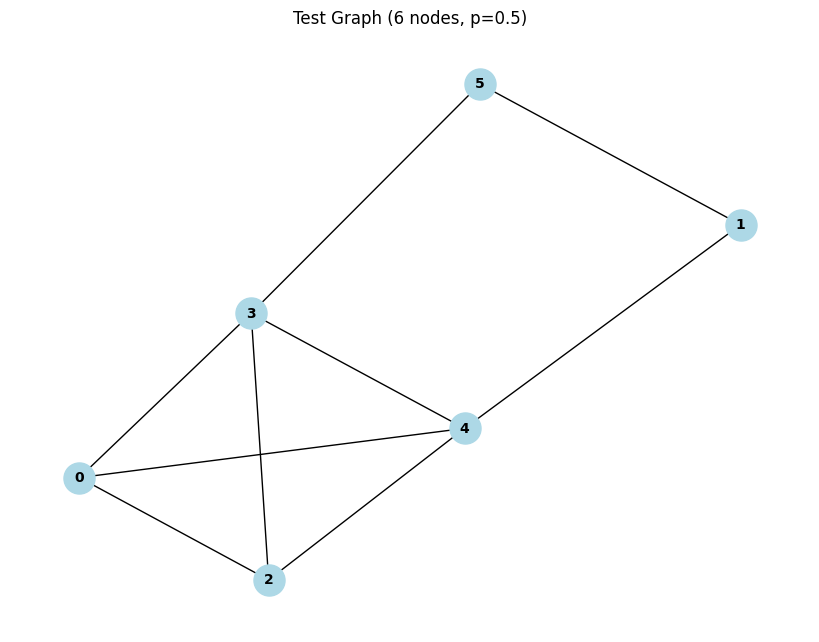


Classical Max-Cut: 7


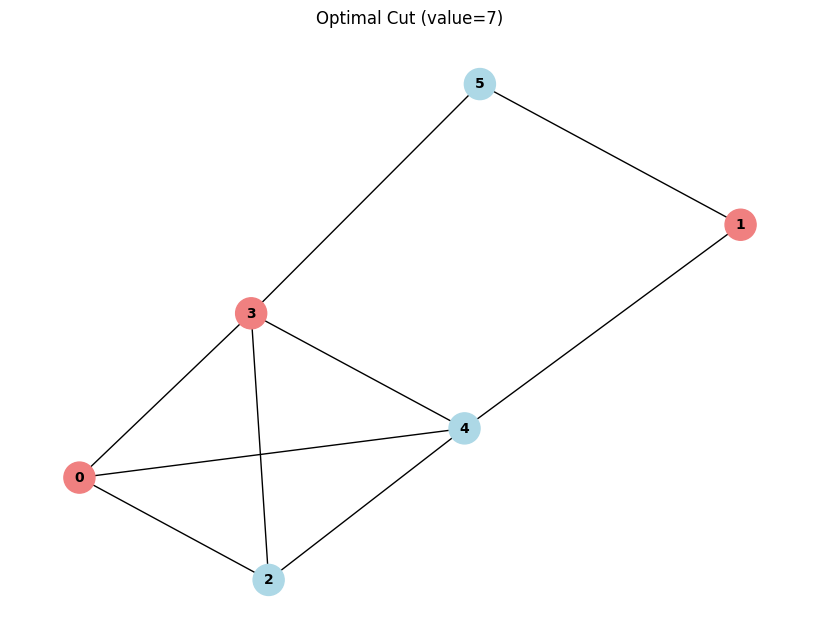


Initializing QuantumDARTS model...
Gate set G = {RzRyRz, I, CNOT} initialized with 32 candidate gates for 6 qubits
Starting training for 50 epochs...
Graph: 6 nodes, 9 edges
Circuit: 6 qubits, 10 layers
Gate set size: 32


Training:   2%|▏         | 1/50 [00:11<09:32, 11.69s/it]


Epoch 0:
  Loss (theta): -4.453640
  Loss (alpha): -4.475757
  Expectation: 4.475757
  CVaR: 6.32
  Temperature: 4.7500


Training:  22%|██▏       | 11/50 [02:04<07:23, 11.37s/it]


Epoch 10:
  Loss (theta): -4.502546
  Loss (alpha): -4.502278
  Expectation: 4.502278
  CVaR: 6.22
  Temperature: 2.8440


...

Training:  82%|████████▏ | 41/50 [07:49<01:42, 11.43s/it]


Epoch 40:
  Loss (theta): -4.511503
  Loss (alpha): -4.513123
  Expectation: 4.513123
  CVaR: 6.25
  Temperature: 0.6104


Training: 100%|██████████| 50/50 [09:29<00:00, 11.39s/it]


Epoch 49:
  Loss (theta): -4.509391
  Loss (alpha): -4.481020
  Expectation: 4.481020
  CVaR: 6.39
  Temperature: 0.3847


Training complete!

Final Results
Total gates: 60
Circuit depth: 10
CVaR (top 20%): 6.54
Classical Max-Cut: 7
Found max cut (CVaR): True

Extracted Max-Cut Solution (from most probable state)
Most probable bitstring: [1, 1, 0, 1, 0, 0]
Partition (x values): [1, 1, -1, 1, -1, -1]
Cut value from solution: 7
Solution probability: 0.041831
Found optimal solution: True


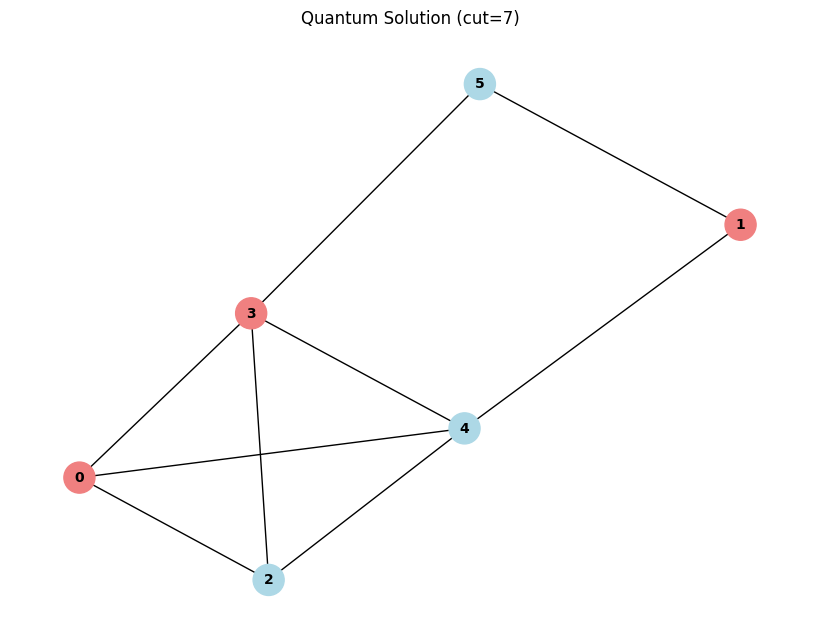


Gate distribution:
  RzRyRz: 35
  CNOT_0_4: 5
  CNOT_5_1: 4
  CNOT_4_0: 3
  CNOT_2_0: 3
  CNOT_3_5: 2
  CNOT_1_4: 2
  CNOT_2_3: 1
  CNOT_5_3: 1
  CNOT_2_4: 1


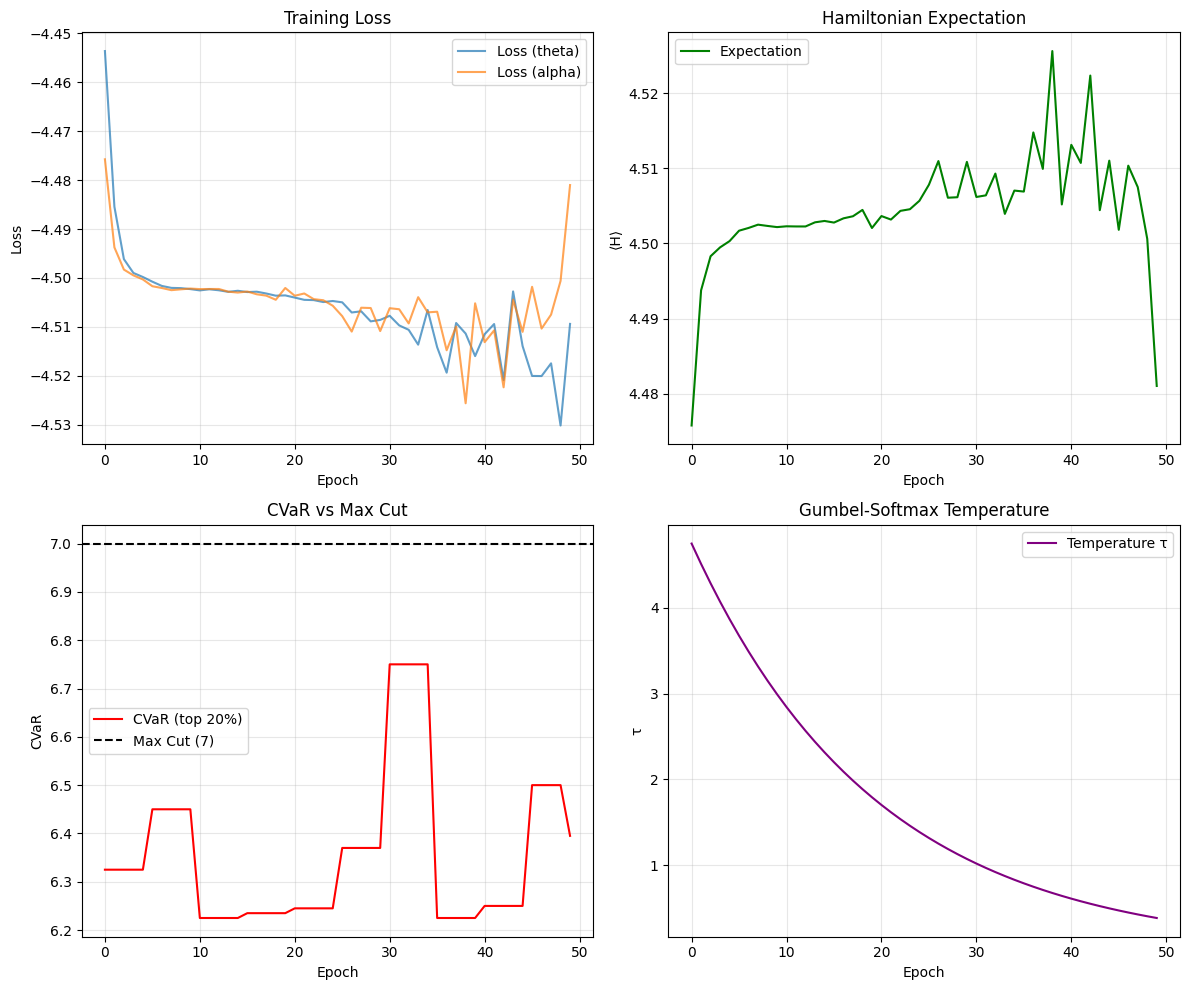

In [ ]:
# Example: Run QuantumDARTS on a small graph first (for testing)
# Then scale up to 10-node graphs as in the paper

# Generate a test graph (start small for debugging)
print("=" * 60)
print("Example 1: Small graph (6 nodes) for quick testing")
print("=" * 60)

test_graph = generate_erdos_renyi_graph(n_nodes=6, p_edge=0.5, seed=42)
visualize_graph_with_cut(test_graph, title="Test Graph (6 nodes, p=0.5)")

# Compute classical max cut
max_cut_classical, best_partition = compute_max_cut_classical(test_graph)
print(f"\nClassical Max-Cut: {max_cut_classical}")
visualize_graph_with_cut(test_graph, partition=best_partition, 
                         title=f"Optimal Cut (value={max_cut_classical})")

# Initialize and train model
print("\n" + "=" * 60)
print("Initializing QuantumDARTS model...")
print("=" * 60)

model = QuantumDARTSMaxCut(
    n_qubits=6,
    n_layers=10,  # Start with fewer layers for testing
    graph=test_graph,
    K_prime=16,
    tau_init=5.0,
    lr_theta=0.01,
    lr_alpha=0.01,
    num_iter=5  # Fewer inner iterations for testing
)

# Train
model.train(num_epochs=50, verbose=True)

# Get results
print("\n" + "=" * 60)
print("Final Results")
print("=" * 60)
circuit_info = model.get_final_circuit_info()
print(f"Total gates: {circuit_info['total_gates']}")
print(f"Circuit depth: {circuit_info['depth']}")
print(f"CVaR (top 20%): {circuit_info['cvar']:.2f}")
print(f"Classical Max-Cut: {circuit_info['max_cut_classical']}")
print(f"Found max cut (CVaR): {circuit_info['found_max_cut']}")

# Display extracted solution (Appendix E)
print(f"\n{'='*60}")
print("Extracted Max-Cut Solution (from most probable state)")
print(f"{'='*60}")
print(f"Most probable bitstring: {circuit_info['best_bitstring']}")
print(f"Partition (x values): {circuit_info['best_partition']}")
print(f"Cut value from solution: {circuit_info['cut_value_from_solution']}")
print(f"Solution probability: {circuit_info['solution_probability']:.6f}")
print(f"Found optimal solution: {circuit_info['found_optimal']}")

# Visualize the found solution
if circuit_info['cut_value_from_solution'] > 0:
    # Convert partition to binary for visualization
    partition_binary = [1 if x == 1 else 0 for x in circuit_info['best_partition']]
    visualize_graph_with_cut(test_graph, partition=partition_binary, 
                             title=f"Quantum Solution (cut={circuit_info['cut_value_from_solution']})")

print(f"\nGate distribution:")
for gate, count in sorted(circuit_info['gate_counts'].items(), key=lambda x: -x[1])[:10]:
    print(f"  {gate}: {count}")

# Plot training history
plot_training_history(model)


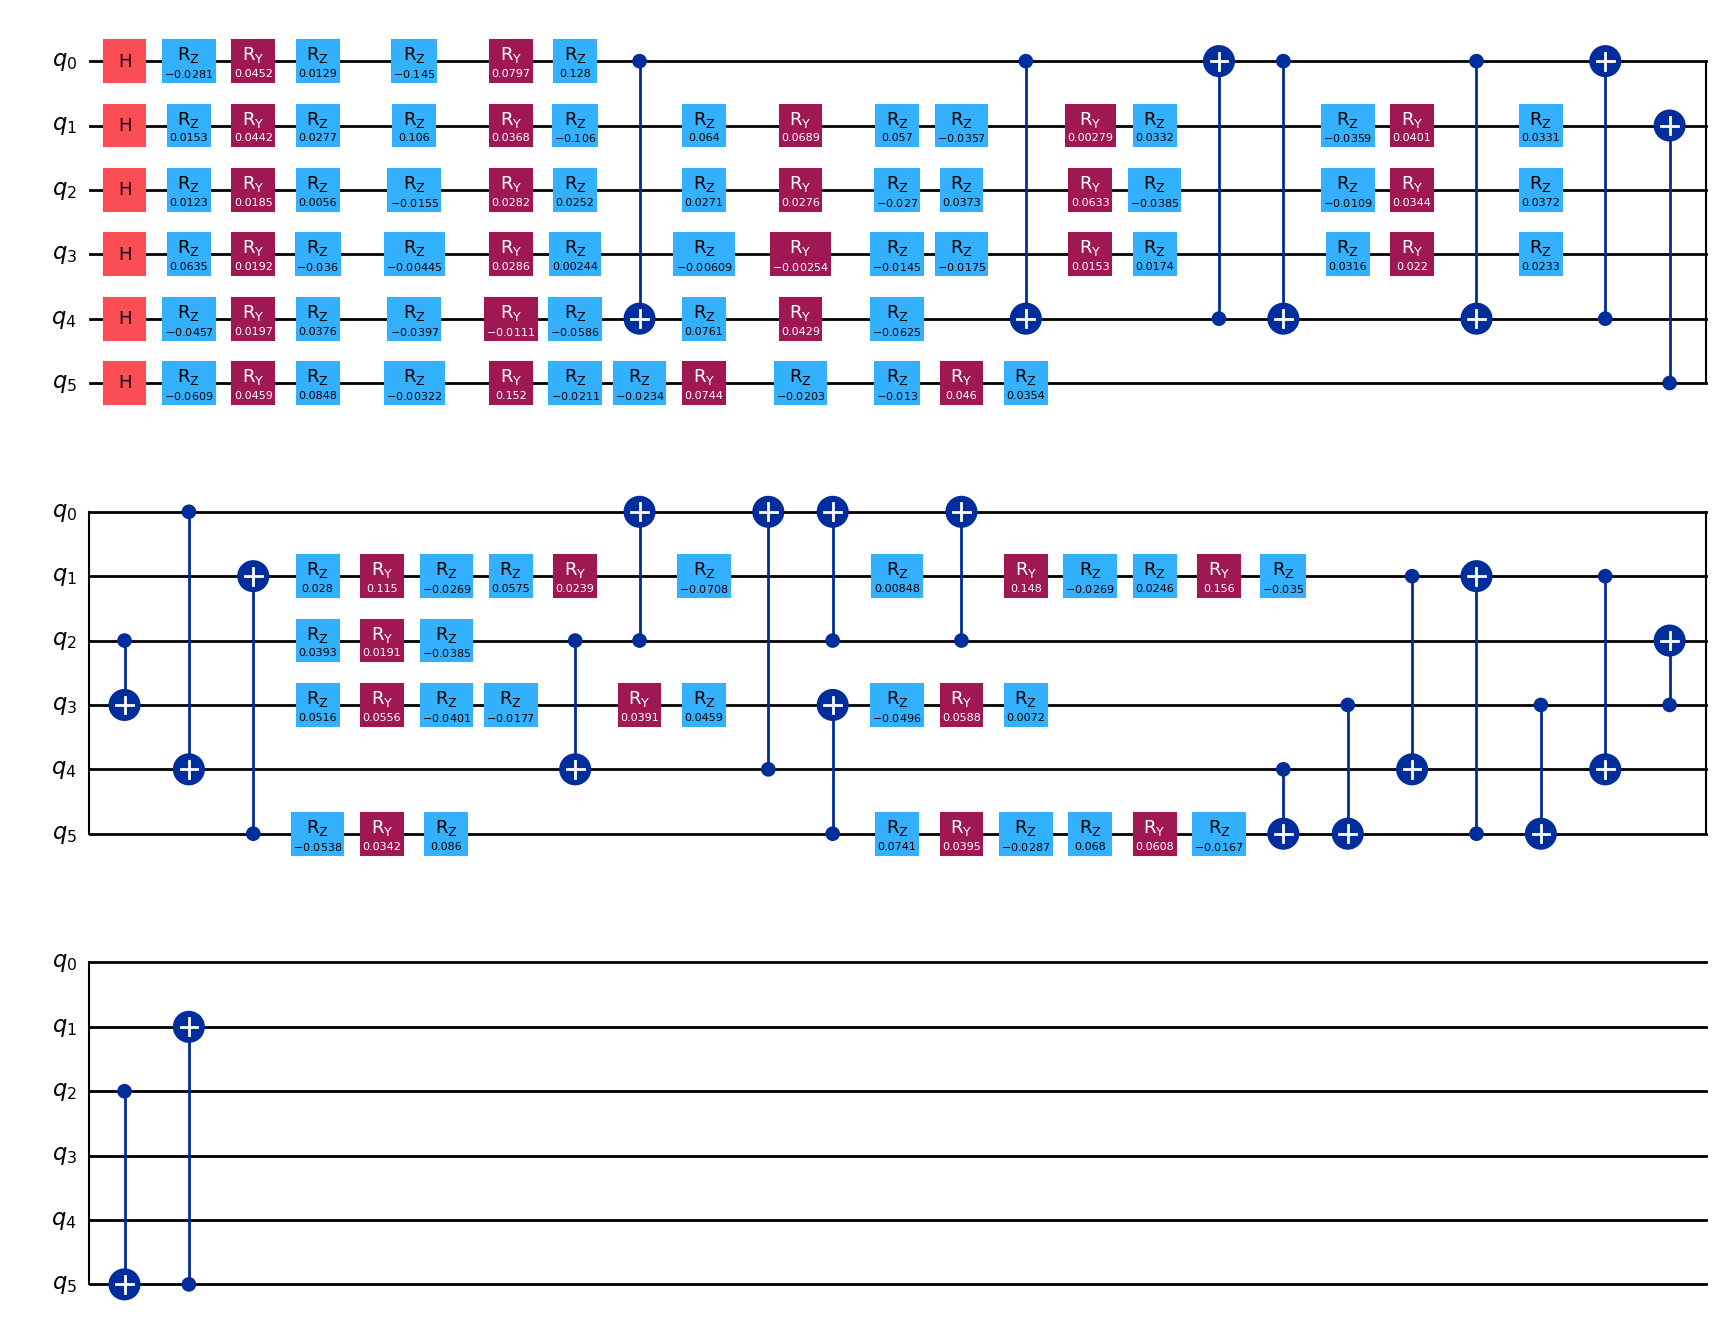

In [ ]:
# Qiskit visualization and noisy simulation helpers
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
import matplotlib.pyplot as plt


def build_qiskit_circuit(model):
    """Convert trained model into a Qiskit circuit (macro or micro)."""
    n = model.n_qubits
    qc = QuantumCircuit(n)
    for q in range(n):
        qc.h(q)
    # Macro path
    if hasattr(model, 'architecture') and hasattr(model, 'circuit'):
        for layer in range(model.n_layers):
            for qubit in range(model.n_qubits):
                alpha_ij = model.architecture.get_alpha_ij(qubit, layer)
                gate_idx = torch.argmax(alpha_ij).item()
                gate_name = model.gate_set.gate_names[gate_idx]
                theta_ij = model.circuit.get_theta_ij(qubit, layer)
                if gate_name == 'I':
                    continue
                elif gate_name == 'RzRyRz':
                    th0, th1, th2 = theta_ij.detach().cpu().numpy().tolist()
                    qc.rz(th0, qubit); qc.ry(th1, qubit); qc.rz(th2, qubit)
                elif gate_name.startswith('CNOT_'):
                    parts = gate_name.split('_'); ctrl, tgt = int(parts[1]), int(parts[2]); qc.cx(ctrl, tgt)
        return qc
    # Micro path - check for both MicroSearchMaxCut and CompilerAwareMicroSearchMaxCut
    if (hasattr(model, 'arch') or hasattr(model, 'architecture')) and hasattr(model, 'subcircuit') and hasattr(model, 'graph'):
        # Use arch if available, otherwise try architecture (for compiler-aware)
        arch = getattr(model, 'arch', getattr(model, 'architecture', None))
        if arch is None:
            raise ValueError("Model has subcircuit but no arch/architecture attribute")
        
        for (u, v) in model.graph.edges():
            for layer in range(model.subcircuit.n_layers):
                for q_local, q_global in enumerate([u, v]):
                    alpha = arch.alpha(q_local, layer)
                    gate_idx = torch.argmax(alpha).item()
                    gname = model.gate_set.gate_names[gate_idx]
                    theta = model.subcircuit.theta_ql(q_local, layer)
                    if gname == 'I':
                        continue
                    elif gname == 'RzRyRz':
                        th0, th1, th2 = theta.detach().cpu().numpy().tolist()
                        qc.rz(th0, q_global); qc.ry(th1, q_global); qc.rz(th2, q_global)
                    elif gname == 'CNOT_0_1' and q_local == 0:
                        qc.cx(u, v)
                    elif gname == 'CNOT_1_0' and q_local == 1:
                        qc.cx(v, u)
        return qc
    raise ValueError(f"Unsupported model type for Qiskit conversion. Model has: {[attr for attr in dir(model) if not attr.startswith('_')]}")

qc = build_qiskit_circuit(model)

qc.draw(output='mpl')

In [38]:
from qiskit_ibm_runtime import QiskitRuntimeService
import os
from pathlib import Path


def load_ibm_credentials(config_path: str = "apikey.json"):
    """Return (token, instance) tuple from env vars or config file."""
    token = os.getenv("QISKIT_IBM_TOKEN")
    instance = os.getenv("QISKIT_IBM_INSTANCE")
    if token:
        return token, instance

    cfg = Path(config_path)
    if cfg.exists():
        try:
            with open(cfg, "r", encoding="utf-8") as f:
                data = json.load(f)
            token = data.get("token") or data.get("apikey")
            instance = instance or data.get("instance") or data.get("crn")
        except Exception as exc:
            print(f"Failed to read IBM credentials from {config_path}: {exc}")
            token = None
            instance = instance
    return token, instance

def connect_ibm_backend(preferred_backend: str = "ibm_torino"):
    """Connect to IBM Quantum using token/env and return (service, backend)."""
    token, instance = load_ibm_credentials()
    backend_name = os.getenv("QISKIT_IBM_BACKEND", preferred_backend)
    channel = os.getenv("QISKIT_IBM_CHANNEL", "ibm_cloud")

    valid_channels = {"ibm_cloud", "ibm_quantum_platform"}
    if channel not in valid_channels:
        print(f"Warning: Unsupported channel '{channel}'. Falling back to 'ibm_cloud'.")
        channel = "ibm_cloud"

    service_kwargs = {}
    if token:
        service_kwargs.update({"channel": channel, "token": token})
        if instance:
            service_kwargs["instance"] = instance
    service = QiskitRuntimeService(**service_kwargs)
    backend = service.backend(backend_name) if backend_name else None
    return service, backend

try:
    service, backend = connect_ibm_backend(preferred_backend="ibm_torino")
    if backend is not None:
        print(f"Using backend: {backend.name}")
    else:
        print("Connected to IBM Quantum, but no backend specified. Set QISKIT_IBM_BACKEND.")
except Exception as e:
    print(f"Could not connect to IBM Quantum backend: {e}")
    print("Running with ideal simulator only. Set backend=None for ideal-only mode.")

qiskit_runtime_service._discover_account:WARNING:2025-12-10 20:29:18,751: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2025-12-10 20:29:22,897: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2025-12-10 20:29:22,897: Using instance: open-instance, plan: open


Using backend: ibm_torino


In [15]:
def noisy_maxcut_value(qc, graph, shots=2000, p_depol=0.003, p_ro=0.02):
    """Simulate circuit on a simple depolarizing + readout noise model and return estimated cut value and CVaR."""
    n = len(graph.nodes())
    # Noise model
    noise_model = NoiseModel.from_backend(backend)
    if p_depol > 0:
        noise_model.add_all_qubit_quantum_error(depolarizing_error(p_depol, 1), ['rz', 'ry'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(p_depol, 2), ['cx'])
    if p_ro > 0:
        ro_err = ReadoutError([[1 - p_ro, p_ro], [p_ro, 1 - p_ro]])
        noise_model.add_all_qubit_readout_error(ro_err)
    sim = AerSimulator(method='automatic', noise_model=noise_model, shots=shots)
    qc_meas = qc.copy()
    qc_meas.measure_all()
    tqc = transpile(qc_meas, sim)
    result = sim.run(tqc).result()
    counts = result.get_counts()
    # Compute cut values and probabilities
    cut_vals = []
    probs = []
    for bitstr, ct in counts.items():
        # Reverse bitstring order from qiskit to match node indexing 0..n-1
        bits = list(map(int, bitstr[::-1]))
        cut = 0
        for u, v in graph.edges():
            if bits[u] != bits[v]:
                cut += 1
        cut_vals.append(cut)
        probs.append(ct / shots)
    import numpy as np
    probs = np.array(probs, dtype=float)
    cut_vals = np.array(cut_vals, dtype=float)
    exp_cut = float((probs * cut_vals).sum())
    # CVaR top 20%
    order = np.argsort(-cut_vals)
    k = max(1, int(len(cut_vals) * 0.2))
    cvar = float(cut_vals[order[:k]].mean())
    return exp_cut, cvar, counts


exp_cut_noisy, cvar_noisy, counts_noisy = noisy_maxcut_value(qc, test_graph, shots=2000)
print(f"Noisy simulator expected cut: {exp_cut_noisy:.2f}, CVaR (top 20%): {cvar_noisy:.2f}")

Noisy simulator expected cut: 4.72, CVaR (top 20%): 6.33


Micro-search: shared 2-qubit subcircuit tiled over edges (6-node graph)
Gate set G = {RzRyRz, I, CNOT} initialized with 4 candidate gates for 2 qubits
Epoch 0: L_theta=-4.3586, L_alpha=-4.4691, CVaR=6.31, tau=5.910
Epoch 10: L_theta=-4.5124, L_alpha=-4.5132, CVaR=6.29, tau=5.081
Epoch 20: L_theta=-4.5151, L_alpha=-4.5131, CVaR=6.30, tau=4.368
Epoch 30: L_theta=-4.5312, L_alpha=-4.5376, CVaR=6.24, tau=3.756
Epoch 40: L_theta=-4.6021, L_alpha=-4.6003, CVaR=6.43, tau=3.229
Epoch 49: L_theta=-4.6356, L_alpha=-4.6407, CVaR=6.37, tau=2.818
Micro-search training complete.

Micro-search results:
{'cvar': 6.515999794006348, 'max_cut_classical': 7, 'best_bitstring': [0, 1, 1, 1, 0, 0], 'best_partition': [-1, 1, 1, 1, -1, -1], 'cut_value': 7, 'solution_prob': 0.04110576584935188, 'found_optimal': True}


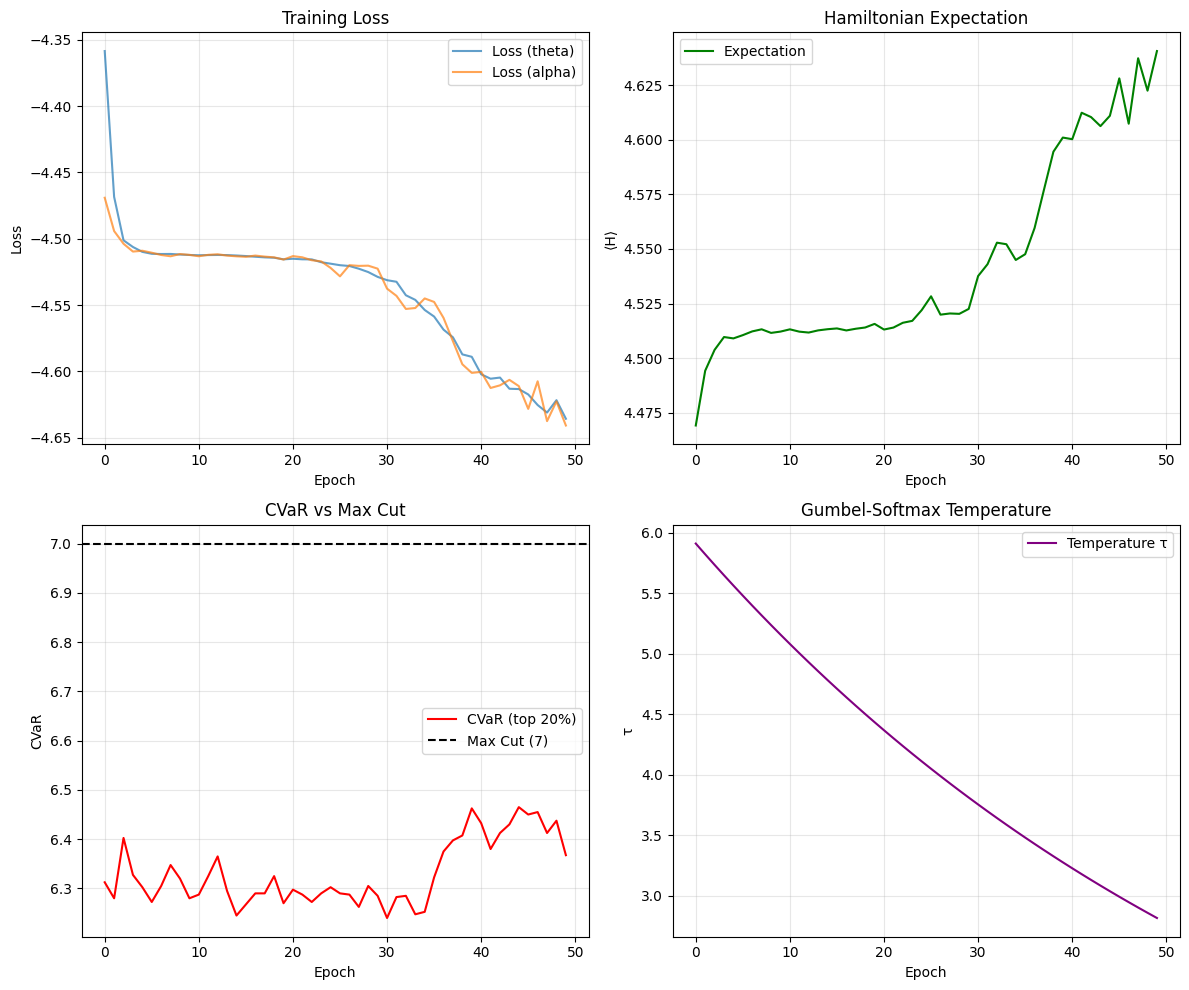

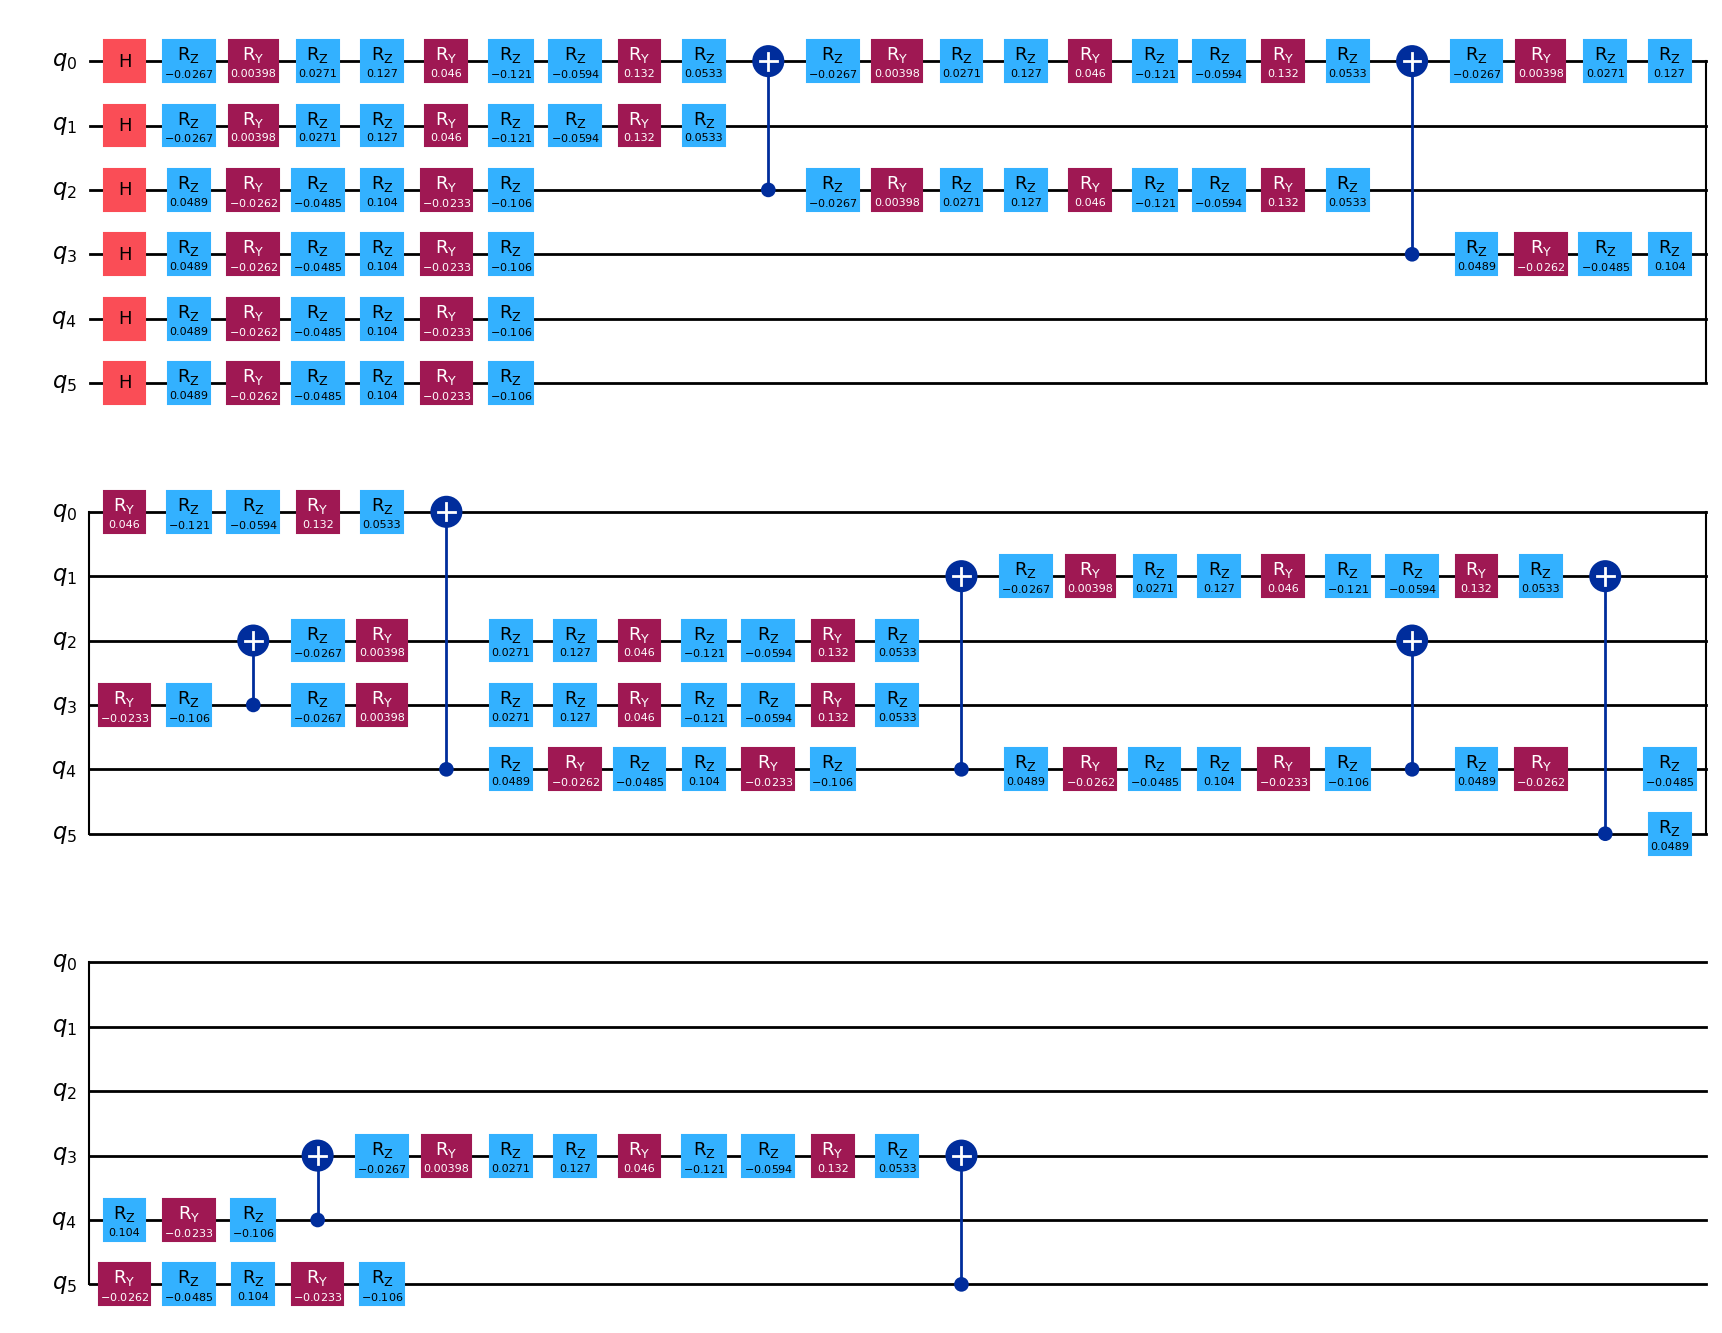

In [22]:
# Micro-search example on the same 6-node graph (lighter than macro on larger graphs)
print("=" * 60)
print("Micro-search: shared 2-qubit subcircuit tiled over edges (6-node graph)")
print("=" * 60)

micro_model = MicroSearchMaxCut(
    n_qubits=6,
    graph=test_graph,
    sub_layers=3,
    K_prime=16,
    tau_init=6.0,
    lr_theta=0.02,
    lr_alpha=0.02,
    num_iter=10,
    sampler_decay=0.985,
    tau_min=0.8,
)

micro_model.train(num_epochs=50, verbose=True)
info = micro_model.get_final_info()
print("\nMicro-search results:")
print(info)

# Plot training history for micro-search
plot_training_history(micro_model)

# Optionally visualize the micro-found circuit
qc_micro = build_qiskit_circuit(micro_model) if 'build_qiskit_circuit' in globals() else None
qc_micro.draw(output='mpl')

## Compiler Aware Quantum Architecture Search using QuantumDARTS

### Overview

This section implements **Compiler-Aware QuantumDARTS** for Micro Search, where the architecture search considers how circuits will be transformed after compilation to IBM Torino hardware topology.

**Key Features:**
- Multi-objective loss: `L = -⟨H⟩ + λ₁·gate_penalty + λ₂·swap_penalty + λ₃·error_penalty`
- Real-time transpilation during training
- Evaluation on noisy simulator with backend properties
- Comparison framework: baseline vs compiler-aware

**Metrics Evaluated:**
- Gate count (before/after compilation)
- Circuit depth (before/after compilation)
- SWAP count
- Logical fidelity (noisy simulator)
- CVaR on noisy simulator
- Expected error rate



In [61]:
# ============================================================================
# Compiler-Aware QuantumDARTS: Helper Functions
# ============================================================================

from qiskit import QuantumCircuit
from qiskit_aer.noise import NoiseModel
import numpy as np

def get_ibm_torino_coupling_map(backend=None):
    """
    Get coupling map from existing backend (assumes backend is already initialized).
    """
    try:
        coupling_map = backend.coupling_map
        return coupling_map
    except Exception as e:
        print(f"Warning: Could not get coupling map from backend: {e}")
        return None

def compile_circuit_metrics(qc, coupling_map=None, backend=None, optimization_level=1):
    """
    Compile circuit and extract metrics using actual backend properties.
    
    Returns:
        dict with keys: gate_count, depth, swap_count, expected_error_rate
    """
    from qiskit import transpile
    
    # Transpile to target topology
    if coupling_map is not None:
        if backend is not None:
            # Use backend for transpilation (includes device properties)
            tqc = transpile(qc, backend=backend, optimization_level=optimization_level)
        else:
            tqc = transpile(qc, coupling_map=coupling_map, optimization_level=optimization_level)
    else:
        if backend is not None:
            tqc = transpile(qc, backend=backend, optimization_level=optimization_level)
        else:
            # No coupling map: just optimize gates
            tqc = transpile(qc, optimization_level=optimization_level)
    
    # Extract metrics
    gate_count = len(tqc.data)
    depth = tqc.depth()
    
    # Count SWAP gates (both explicit and decomposed)
    # Explicit SWAP gates
    explicit_swaps = sum(1 for inst in tqc.data if inst.operation.name == 'swap')
    
    # Count decomposed SWAPs: pattern is CNOT(a,b), CNOT(b,a), CNOT(a,b)
    # This is the standard decomposition: SWAP = CNOT(a,b) * CNOT(b,a) * CNOT(a,b)
    decomposed_swaps = 0
    i = 0
    while i < len(tqc.data) - 2:
        inst1 = tqc.data[i]
        inst2 = tqc.data[i+1] if i+1 < len(tqc.data) else None
        inst3 = tqc.data[i+2] if i+2 < len(tqc.data) else None
        
        if (inst1.operation.name == 'cx' and inst2 and inst2.operation.name == 'cx' and 
            inst3 and inst3.operation.name == 'cx'):
            # Get qubit indices directly from instruction
            try:
                # Get physical qubit indices
                q1_1 = tqc.find_bit(inst1.qubits[0]).index
                q2_1 = tqc.find_bit(inst1.qubits[1]).index
                q1_2 = tqc.find_bit(inst2.qubits[0]).index
                q2_2 = tqc.find_bit(inst2.qubits[1]).index
                q1_3 = tqc.find_bit(inst3.qubits[0]).index
                q2_3 = tqc.find_bit(inst3.qubits[1]).index
                
                # Check for SWAP pattern: CNOT(a,b), CNOT(b,a), CNOT(a,b)
                # Pattern: CNOT(a,b) -> CNOT(b,a) -> CNOT(a,b)
                if ((q1_1, q2_1) == (q1_3, q2_3) and  # First and third CNOT are same: CNOT(a,b)
                    (q1_2, q2_2) == (q2_1, q1_1)):    # Second CNOT is reversed: CNOT(b,a)
                    decomposed_swaps += 1
                    i += 3  # Skip these three gates
                    continue
            except Exception as e:
                # If find_bit fails, try alternative method
                try:
                    # Alternative: use qubit register index
                    q1_1 = inst1.qubits[0].index if hasattr(inst1.qubits[0], 'index') else None
                    q2_1 = inst1.qubits[1].index if hasattr(inst1.qubits[1], 'index') else None
                    q1_2 = inst2.qubits[0].index if hasattr(inst2.qubits[0], 'index') else None
                    q2_2 = inst2.qubits[1].index if hasattr(inst2.qubits[1], 'index') else None
                    q1_3 = inst3.qubits[0].index if hasattr(inst3.qubits[0], 'index') else None
                    q2_3 = inst3.qubits[1].index if hasattr(inst3.qubits[1], 'index') else None
                    
                    if (q1_1 is not None and q2_1 is not None and q1_2 is not None and 
                        q2_2 is not None and q1_3 is not None and q2_3 is not None):
                        if ((q1_1, q2_1) == (q1_3, q2_3) and (q1_2, q2_2) == (q2_1, q1_1)):
                            decomposed_swaps += 1
                            i += 3
                            continue
                except:
                    pass
        i += 1
    
    swap_count = explicit_swaps + decomposed_swaps
    
    # Also check raw routing (optimization_level=0) to see if SWAPs are being optimized away
    raw_swap_count = 0
    if backend is not None or coupling_map is not None:
        try:
            if backend is not None:
                tqc_raw = transpile(qc, backend=backend, optimization_level=0)
            else:
                tqc_raw = transpile(qc, coupling_map=coupling_map, optimization_level=0)
            
            # Count raw SWAPs (before optimization)
            raw_explicit = sum(1 for inst in tqc_raw.data if inst.operation.name == 'swap')
            # Count decomposed SWAPs in raw circuit (same logic as above)
            raw_decomposed = 0
            i = 0
            while i < len(tqc_raw.data) - 2:
                inst1 = tqc_raw.data[i]
                inst2 = tqc_raw.data[i+1] if i+1 < len(tqc_raw.data) else None
                inst3 = tqc_raw.data[i+2] if i+2 < len(tqc_raw.data) else None
                if (inst1.operation.name == 'cx' and inst2 and inst2.operation.name == 'cx' and 
                    inst3 and inst3.operation.name == 'cx'):
                    try:
                        q1_1 = tqc_raw.find_bit(inst1.qubits[0]).index
                        q2_1 = tqc_raw.find_bit(inst1.qubits[1]).index
                        q1_2 = tqc_raw.find_bit(inst2.qubits[0]).index
                        q2_2 = tqc_raw.find_bit(inst2.qubits[1]).index
                        q1_3 = tqc_raw.find_bit(inst3.qubits[0]).index
                        q2_3 = tqc_raw.find_bit(inst3.qubits[1]).index
                        if ((q1_1, q2_1) == (q1_3, q2_3) and (q1_2, q2_2) == (q2_1, q1_1)):
                            raw_decomposed += 1
                            i += 3
                            continue
                    except Exception as e:
                        try:
                            q1_1 = inst1.qubits[0].index if hasattr(inst1.qubits[0], 'index') else None
                            q2_1 = inst1.qubits[1].index if hasattr(inst1.qubits[1], 'index') else None
                            q1_2 = inst2.qubits[0].index if hasattr(inst2.qubits[0], 'index') else None
                            q2_2 = inst2.qubits[1].index if hasattr(inst2.qubits[1], 'index') else None
                            q1_3 = inst3.qubits[0].index if hasattr(inst3.qubits[0], 'index') else None
                            q2_3 = inst3.qubits[1].index if hasattr(inst3.qubits[1], 'index') else None
                            if (q1_1 is not None and q2_1 is not None and q1_2 is not None and 
                                q2_2 is not None and q1_3 is not None and q2_3 is not None):
                                if ((q1_1, q2_1) == (q1_3, q2_3) and (q1_2, q2_2) == (q2_1, q1_1)):
                                    raw_decomposed += 1
                                    i += 3
                                    continue
                        except:
                            pass
                i += 1
            raw_swap_count = raw_explicit + raw_decomposed
        except Exception as e:
            pass  # Silently fail for raw routing check
    
    # Compute expected error rate from actual backend properties
    expected_error_rate = 0.0
    gates_with_errors = 0  # Track gates that couldn't get error rates
    if backend is not None:
        try:
            props = backend.properties()
            # Sum error rates for all gates in the compiled circuit
            for inst in tqc.data:
                # Get qubit indices properly (handle Qubit objects)
                # Use find_bit which is the recommended method in modern Qiskit
                qubits = []
                for qubit in inst.qubits:
                    try:
                        # Modern Qiskit: use find_bit to get the index
                        bit_loc = tqc.find_bit(qubit)
                        idx = bit_loc.index
                        qubits.append(idx)
                    except (AttributeError, ValueError, TypeError):
                        # Fallback: try direct attribute access (older Qiskit)
                        try:
                            idx = getattr(qubit, 'index', getattr(qubit, '_index', None))
                            if idx is not None:
                                qubits.append(idx)
                        except:
                            pass
                
                if not qubits:
                    gates_with_errors += 1
                    continue
                    
                gate_name = inst.operation.name
                gate_error_found = False
                
                # Get error rate from backend properties
                if len(qubits) == 1:
                    # Single-qubit gate
                    try:
                        error = props.gate_error(gate_name, qubits[0])
                        if error is not None:
                            expected_error_rate += error
                            gate_error_found = True
                    except:
                        # Fallback: use average single-qubit error
                        try:
                            errors = []
                            for q in range(backend.num_qubits):
                                try:
                                    err = props.gate_error(gate_name, q)
                                    if err is not None:
                                        errors.append(err)
                                except:
                                    pass
                            if errors:
                                error = np.mean(errors)
                                expected_error_rate += error
                                gate_error_found = True
                        except:
                            pass
                elif len(qubits) == 2:
                    # Two-qubit gate
                    try:
                        error = props.gate_error(gate_name, qubits)
                        if error is not None:
                            expected_error_rate += error
                            gate_error_found = True
                    except:
                        # Fallback: use average two-qubit error
                        try:
                            errors = []
                            for edge in backend.coupling_map:
                                try:
                                    err = props.gate_error(gate_name, list(edge))
                                    if err is not None:
                                        errors.append(err)
                                except:
                                    pass
                            if errors:
                                error = np.mean(errors)
                                expected_error_rate += error
                                gate_error_found = True
                        except:
                            pass
                
                if not gate_error_found:
                    gates_with_errors += 1
                    
            # If many gates failed, use fallback estimate
            if gates_with_errors > gate_count * 0.5:  # More than 50% failed
                if expected_error_rate == 0.0:
                    gate_error_rate = 0.001  # 0.1% per gate
                    expected_error_rate = gate_count * gate_error_rate
        except Exception as e:
            # Fallback: estimate based on typical values
            gate_error_rate = 0.001  # 0.1% per gate
            expected_error_rate = gate_count * gate_error_rate
    else:
        # No backend: use estimated error rate
        gate_error_rate = 0.001  # 0.1% per gate
        expected_error_rate = gate_count * gate_error_rate
    
    result = {
        'gate_count': gate_count,
        'depth': depth,
        'swap_count': swap_count,
        'expected_error_rate': expected_error_rate,
        'compiled_circuit': tqc,
        'raw_swap_count': raw_swap_count,  # SWAPs before optimization
        'explicit_swaps': explicit_swaps,
        'decomposed_swaps': decomposed_swaps
    }
    
    # Diagnostic: if raw_swap_count > 0 but swap_count == 0, optimization removed SWAPs
    if raw_swap_count > 0 and swap_count == 0:
        result['swaps_optimized_away'] = True
    else:
        result['swaps_optimized_away'] = False
    
    return result

def compiler_aware_loss(expectation, compiled_metrics, weights=(0.1, 0.1, 0.1), 
                        baseline_gates=100, normalize=True):
    """
    Compute compiler-aware loss with penalties.
    
    Args:
        expectation: Hamiltonian expectation value (negative for minimization)
        compiled_metrics: dict from compile_circuit_metrics
        weights: (λ₁, λ₂, λ₃) for gate, swap, error penalties
        baseline_gates: normalization factor for gate penalty
        normalize: whether to normalize penalties
    
    Returns:
        total_loss, penalty_dict
    """
    λ_gate, λ_swap, λ_error = weights
    
    # Gate penalty: normalized gate count overhead
    if normalize:
        gate_penalty = compiled_metrics['gate_count'] / baseline_gates
    else:
        gate_penalty = compiled_metrics['gate_count'] / 100.0  # per 100 gates
    
    # SWAP penalty: ratio of SWAPs to total gates
    if compiled_metrics['gate_count'] > 0:
        swap_penalty = compiled_metrics['swap_count'] / compiled_metrics['gate_count']
    else:
        swap_penalty = 0.0
    
    # Error penalty: expected error rate (already normalized)
    error_penalty = compiled_metrics['expected_error_rate']
    
    # Total loss: -expectation (maximize cut) + penalties (minimize overhead)
    total_loss = -expectation + λ_gate * gate_penalty + λ_swap * swap_penalty + λ_error * error_penalty
    
    return total_loss, {
        'gate_penalty': gate_penalty,
        'swap_penalty': swap_penalty,
        'error_penalty': error_penalty,
        'total_penalty': λ_gate * gate_penalty + λ_swap * swap_penalty + λ_error * error_penalty
    }

def evaluate_on_noisy_simulator(qc, backend=None, shots=5000, noise_model=None):
    """
    Evaluate circuit on noisy simulator using actual backend properties.
    
    Returns:
        dict with fidelity, counts, shots
    """
    from qiskit_aer import AerSimulator
    from qiskit import transpile
    
    
    # Create noise model from actual backend properties
    if noise_model is None:
        if backend is not None:
            try:
                # Use actual backend properties for noise model
                noise_model = NoiseModel.from_backend(backend)
            except Exception as e:
                print(f"Warning: Could not create noise model from backend: {e}")
                # Fallback: use backend properties directly
                try:
                    props = backend.properties()
                    noise_model = NoiseModel.from_backend_properties(props)
                except Exception as e2:
                    print(f"Warning: Could not create noise model from backend properties: {e2}")
                    noise_model = None
        
        # If still no noise model, create simplified one (should not happen if backend is available)
        if noise_model is None:
            print("Warning: Using simplified noise model (backend not available)")
            from qiskit_aer.noise import depolarizing_error, ReadoutError
            noise_model = NoiseModel()
            noise_model.add_all_qubit_quantum_error(depolarizing_error(0.001, 1), ['rz', 'ry'])
            noise_model.add_all_qubit_quantum_error(depolarizing_error(0.01, 2), ['cx'])
            noise_model.add_all_qubit_readout_error(ReadoutError([[0.98, 0.02], [0.02, 0.98]]))
    
    # Run on noisy simulator
    sim = AerSimulator(noise_model=noise_model)
    qc_meas = qc.copy()
    qc_meas.measure_all()
    
    # Transpile using backend if available
    if backend is not None:
        tqc = transpile(qc_meas, backend=backend)
    else:
        tqc = transpile(qc_meas, sim)
    
    result = sim.run(tqc, shots=shots).result()
    counts = result.get_counts()
    
    # Compute fidelity (probability of most likely state)
    if counts:
        max_count = max(counts.values())
        fidelity = max_count / shots
    else:
        fidelity = 0.0
    
    return {
        'fidelity': fidelity,
        'counts': counts,
        'shots': shots
    }



In [ ]:
# ============================================================================
# Compiler-Aware Micro Search Class
# ============================================================================

class CompilerAwareMicroSearchMaxCut:
    """
    Micro-search with compiler awareness: loss includes compilation penalties.
    """
    def __init__(self, n_qubits, graph, sub_layers=3, K_prime=16, tau_init=5.0,
                 lr_theta=0.02, lr_alpha=0.02, num_iter=12, sampler_decay=0.98, tau_min=0.1,
                 loss_weights=(0.1, 0.1, 0.1), coupling_map=None, compile_every_n_epochs=5, 
                 backend=None, baseline_gates=None):
        self.n_qubits = n_qubits
        self.graph = graph
        self.num_iter = num_iter
        self.loss_weights = loss_weights  # (λ_gate, λ_swap, λ_error)
        self.coupling_map = coupling_map
        self.compile_every_n_epochs = compile_every_n_epochs  # Compile less frequently for speed
        
        # Store backend (use global if not provided)

        self.backend = backend
        
        # Get coupling map from backend if not provided
        if self.coupling_map is None and self.backend is not None:
            self.coupling_map = get_ibm_torino_coupling_map(backend=self.backend)
        
        # Gate set for 2-qubit micro
        self.gate_set = GateSet(2, include_entangling=True)
        self.gate_set.gate_names = ['I', 'RzRyRz', 'CNOT_0_1', 'CNOT_1_0']
        self.gate_set.K = len(self.gate_set.gate_names)
        K = self.gate_set.K
        
        # Architecture and circuit (same as MicroSearchMaxCut)
        self.arch = MicroSubArchitecture(sub_layers, K, K_prime)
        self.sampler = GumbelSoftmaxGateSampler(K, tau_init)
        self.subcircuit = MicroSubCircuit(sub_layers, self.gate_set, self.sampler)
        
        # Hamiltonian and initial state
        self.H_c = build_maxcut_hamiltonian(graph)
        self.psi_h = prepare_initial_state(n_qubits)
        
        # Optimizers
        self.optimizer_theta = optim.Adam(self.subcircuit.parameters(), lr=lr_theta)
        self.optimizer_alpha = optim.Adam(list(self.arch.P.values()) + list(self.arch.Q.values()), lr=lr_alpha)
        
        self.sampler_decay = sampler_decay
        self.tau_min = tau_min
        
        # History with compiler metrics
        self.history = {
            'loss_theta': [], 'loss_alpha': [], 'expectation': [], 'cvar': [], 'tau': [],
            'gate_count': [], 'depth': [], 'swap_count': [], 'error_rate': [],
            'gate_penalty': [], 'swap_penalty': [], 'error_penalty': []
        }
        
        # Baseline for normalization (use provided value or set after first compilation)
        if baseline_gates is not None:
            self.baseline_gates = baseline_gates
        else:
            self.baseline_gates = 100  # Default, will be updated after first compilation

    def full_unitary(self, use_soft=False):
        """Same as MicroSearchMaxCut"""
        U = torch.eye(2**self.n_qubits, dtype=torch.complex64, device=DEVICE)
        U_sub = self.subcircuit.sub_unitary(self.arch, use_soft=use_soft)
        for (u,v) in self.graph.edges():
            U_edge = embed_2q_unitary(U_sub, u, v, self.n_qubits)
            U = U_edge @ U
        return U

    def get_qiskit_circuit(self, use_soft=False):
        """Convert to Qiskit circuit for compilation"""
        qc = QuantumCircuit(self.n_qubits)
        for q in range(self.n_qubits):
            qc.h(q)
        # Build circuit from architecture
        for (u, v) in self.graph.edges():
            for layer in range(self.subcircuit.n_layers):
                for q_local, q_global in enumerate([u, v]):
                    alpha = self.arch.alpha(q_local, layer)
                    if use_soft:
                        h_ql = self.sampler(alpha, use_soft=True)
                        gate_idx = torch.argmax(h_ql).item()
                    else:
                        gate_idx = torch.argmax(alpha).item()
                    gname = self.gate_set.gate_names[gate_idx]
                    theta = self.subcircuit.theta_ql(q_local, layer)
                    if gname == 'I':
                        continue
                    elif gname == 'RzRyRz':
                        th0, th1, th2 = theta.detach().cpu().numpy().tolist()
                        qc.rz(th0, q_global)
                        qc.ry(th1, q_global)
                        qc.rz(th2, q_global)
                    elif gname == 'CNOT_0_1' and q_local == 0:
                        qc.cx(u, v)
                    elif gname == 'CNOT_1_0' and q_local == 1:
                        qc.cx(v, u)
        return qc

    def train_epoch(self, epoch, num_epochs):
        """Training epoch with compiler-aware loss"""
        # Theta update
        loss_theta_epoch = []
        self.subcircuit.train()
        self.arch.eval()
        
        for _ in range(self.num_iter):
            self.optimizer_theta.zero_grad()
            U_c = self.full_unitary(use_soft=True)
            loss_theta, expv = compute_loss(U_c, self.H_c, self.psi_h)
            
            # Add compiler penalties (only compile occasionally for speed)
            # Note: compilation is non-differentiable, so penalty is a constant guide
            if epoch % self.compile_every_n_epochs == 0:
                # Compute penalty (non-differentiable compilation)
                with torch.no_grad():
                    qc = self.get_qiskit_circuit(use_soft=True)
                    compiled_metrics = compile_circuit_metrics(qc, self.coupling_map, backend=self.backend, optimization_level=1)
                    # Only set baseline_gates if it's still the default (wasn't provided as parameter)
                    if epoch == 0 and self.baseline_gates == 100:
                        self.baseline_gates = compiled_metrics['gate_count']
                    
                    _, penalties = compiler_aware_loss(
                        expv.item(), compiled_metrics, self.loss_weights, 
                        self.baseline_gates, normalize=True
                    )
                    penalty_value = float(penalties['total_penalty'])
                
                # Add penalty as scalar - this preserves gradient flow of loss_theta
                # When adding a Python float to a tensor, PyTorch preserves gradients
                loss_theta = loss_theta + penalty_value
            
            loss_theta.backward()
            self.optimizer_theta.step()
            loss_theta_epoch.append(loss_theta.item())
        
        # Alpha update
        self.subcircuit.eval()
        self.arch.train()
        self.optimizer_alpha.zero_grad()
        U_c_soft = self.full_unitary(use_soft=True)
        loss_alpha, expv_alpha = compute_loss(U_c_soft, self.H_c, self.psi_h)
        
        # Add compiler penalties for alpha update
        if epoch % self.compile_every_n_epochs == 0:
            # Compute penalty (non-differentiable compilation)
            with torch.no_grad():
                qc = self.get_qiskit_circuit(use_soft=True)
                compiled_metrics = compile_circuit_metrics(qc, self.coupling_map, backend=self.backend, optimization_level=1)
                _, penalties = compiler_aware_loss(
                    expv_alpha.item(), compiled_metrics, self.loss_weights,
                    self.baseline_gates, normalize=True
                )
                penalty_value = float(penalties['total_penalty'])
            
            # Add penalty as scalar - preserves gradient flow
            loss_alpha = loss_alpha + penalty_value
        
        loss_alpha.backward()
        self.optimizer_alpha.step()
        
        # Anneal temperature
        self.sampler.anneal_temperature(decay_factor=self.sampler_decay, min_tau=self.tau_min)
        
        # Logging
        self.history['loss_theta'].append(sum(loss_theta_epoch)/len(loss_theta_epoch))
        self.history['loss_alpha'].append(loss_alpha.item())
        self.history['expectation'].append(expv_alpha.item())
        self.history['tau'].append(self.sampler.tau)
        
        # Compile and log metrics (every N epochs)
        if epoch % self.compile_every_n_epochs == 0:
            with torch.no_grad():
                qc = self.get_qiskit_circuit(use_soft=False)
                compiled_metrics = compile_circuit_metrics(qc, self.coupling_map, backend=self.backend, optimization_level=1)
                _, penalties = compiler_aware_loss(
                    expv_alpha.item(), compiled_metrics, self.loss_weights,
                    self.baseline_gates, normalize=True
                )
                self.history['gate_count'].append(compiled_metrics['gate_count'])
                self.history['depth'].append(compiled_metrics['depth'])
                self.history['swap_count'].append(compiled_metrics['swap_count'])
                self.history['error_rate'].append(compiled_metrics['expected_error_rate'])
                self.history['gate_penalty'].append(penalties['gate_penalty'])
                self.history['swap_penalty'].append(penalties['swap_penalty'])
                self.history['error_penalty'].append(penalties['error_penalty'])
        else:
            # Reuse last values
            if self.history['gate_count']:
                self.history['gate_count'].append(self.history['gate_count'][-1])
                self.history['depth'].append(self.history['depth'][-1])
                self.history['swap_count'].append(self.history['swap_count'][-1])
                self.history['error_rate'].append(self.history['error_rate'][-1])
                self.history['gate_penalty'].append(self.history['gate_penalty'][-1])
                self.history['swap_penalty'].append(self.history['swap_penalty'][-1])
                self.history['error_penalty'].append(self.history['error_penalty'][-1])
        
        # CVaR eval
        with torch.no_grad():
            U_eval = self.full_unitary(use_soft=False)
            cut_vals, probs = evaluate_circuit_output(U_eval, self.psi_h, self.graph, n_shots=2000)
            cvar = compute_cvar(probs, cut_vals, cvar_frac=0.2)
        self.history['cvar'].append(cvar)
        
        return {
            'loss_theta': self.history['loss_theta'][-1],
            'loss_alpha': self.history['loss_alpha'][-1],
            'expectation': self.history['expectation'][-1],
            'cvar': cvar,
            'tau': self.sampler.tau,
            'gate_count': self.history['gate_count'][-1] if self.history['gate_count'] else 0,
            'swap_count': self.history['swap_count'][-1] if self.history['swap_count'] else 0
        }

    def train(self, num_epochs=60, verbose=True):
        """Train with compiler-aware loss"""
        for epoch in range(num_epochs):
            metrics = self.train_epoch(epoch, num_epochs)
            if verbose and (epoch % 10 == 0 or epoch == num_epochs-1):
                print(f"Epoch {epoch}: L_theta={metrics['loss_theta']:.4f}, "
                      f"L_alpha={metrics['loss_alpha']:.4f}, CVaR={metrics['cvar']:.2f}, "
                      f"Gates={metrics['gate_count']}, SWAPs={metrics['swap_count']}, "
                      f"tau={metrics['tau']:.3f}")
        
        # Final theta refinement
        self.subcircuit.train()
        self.arch.eval()
        for _ in range(self.num_iter * 2):
            self.optimizer_theta.zero_grad()
            U_c = self.full_unitary(use_soft=True)
            loss_theta, _ = compute_loss(U_c, self.H_c, self.psi_h)
            loss_theta.backward()
            self.optimizer_theta.step()
        print("Compiler-aware micro-search training complete.")

    def get_final_info(self, noisy_eval=True, shots=5000):
        """Get final metrics including compilation and noisy evaluation"""
        self.subcircuit.eval()
        self.arch.eval()
        
        with torch.no_grad():
            # Get final circuit
            U_c = self.full_unitary(use_soft=False)
            qc = self.get_qiskit_circuit(use_soft=False)
            
            # Compilation metrics
            compiled_metrics = compile_circuit_metrics(qc, self.coupling_map, backend=self.backend, optimization_level=2)
            
            # Ideal evaluation
            cut_vals, probs = evaluate_circuit_output(U_c, self.psi_h, self.graph, n_shots=shots)
            cvar = compute_cvar(probs, cut_vals, cvar_frac=0.2)
            max_cut_classical, _ = compute_max_cut_classical(self.graph)
            psi_final = torch.matmul(U_c, self.psi_h)
            best_bitstring, best_partition, cut_value_solution, prob = extract_max_cut_solution(psi_final, self.graph)
            
            result = {
                'cvar': cvar,
                'max_cut_classical': max_cut_classical,
                'best_bitstring': best_bitstring,
                'best_partition': best_partition,
                'cut_value': cut_value_solution,
                'solution_prob': prob,
                'found_optimal': cut_value_solution == max_cut_classical,
                # Compilation metrics
                'gate_count': compiled_metrics['gate_count'],
                'depth': compiled_metrics['depth'],
                'swap_count': compiled_metrics['swap_count'],
                'expected_error_rate': compiled_metrics['expected_error_rate'],
                'compiled_circuit': compiled_metrics['compiled_circuit']
            }
            
            # Noisy evaluation
            if noisy_eval:
                noisy_results = evaluate_on_noisy_simulator(qc, backend=self.backend, shots=shots)
                result['noisy_fidelity'] = noisy_results['fidelity']
                result['noisy_counts'] = noisy_results['counts']
                
                # Compute CVaR on noisy results
                if noisy_results['counts']:
                    cut_vals_noisy = []
                    probs_noisy = []
                    for bitstr, count in noisy_results['counts'].items():
                        bits = list(map(int, bitstr[::-1]))
                        cut = 0
                        for u, v in self.graph.edges():
                            if bits[u] != bits[v]:
                                cut += 1
                        cut_vals_noisy.append(cut)
                        probs_noisy.append(count / shots)
                    if cut_vals_noisy:
                        cut_vals_noisy = torch.tensor(cut_vals_noisy, dtype=torch.float32)
                        probs_noisy = torch.tensor(probs_noisy, dtype=torch.float32)
                        result['noisy_cvar'] = compute_cvar(probs_noisy, cut_vals_noisy, cvar_frac=0.2)
            
            return result



In [63]:
# ============================================================================
# Comparison and Visualization Functions
# ============================================================================

def compare_baseline_vs_compiler_aware(baseline_model, compiler_aware_model, graph, save_path=None):
    """
    Compare baseline (standard micro-search) vs compiler-aware models.
    
    Args:
        baseline_model: MicroSearchMaxCut instance
        compiler_aware_model: CompilerAwareMicroSearchMaxCut instance
        graph: NetworkX graph
        save_path: optional path to save figures
    """
    # Get final info from both models
    try:
        baseline_info = baseline_model.get_final_info()
    except Exception as e:
        print(f"Error getting baseline info: {e}")
        raise
    
    try:
        compiler_info = compiler_aware_model.get_final_info(noisy_eval=True)
    except Exception as e:
        print(f"Error getting compiler-aware info: {e}")
        raise
    
    # Compile baseline circuit for comparison
    try:
        baseline_qc = build_qiskit_circuit(baseline_model)
    except Exception as e:
        print(f"Error building baseline Qiskit circuit: {e}")
        raise
    
    try:
        # Use backend from compiler_aware_model
        backend = getattr(compiler_aware_model, 'backend', None)
        baseline_compiled = compile_circuit_metrics(baseline_qc, compiler_aware_model.coupling_map, backend=backend, optimization_level=2)
        baseline_noisy = evaluate_on_noisy_simulator(baseline_qc, backend=backend, shots=5000)
    except Exception as e:
        print(f"Error compiling/evaluating baseline circuit: {e}")
        raise
    
    # Compute baseline noisy CVaR
    if baseline_noisy['counts']:
        cut_vals_baseline = []
        probs_baseline = []
        for bitstr, count in baseline_noisy['counts'].items():
            bits = list(map(int, bitstr[::-1]))
            cut = 0
            for u, v in graph.edges():
                if bits[u] != bits[v]:
                    cut += 1
            cut_vals_baseline.append(cut)
            probs_baseline.append(count / 5000)
        if cut_vals_baseline:
            cut_vals_baseline = torch.tensor(cut_vals_baseline, dtype=torch.float32)
            probs_baseline = torch.tensor(probs_baseline, dtype=torch.float32)
            baseline_noisy_cvar = compute_cvar(probs_baseline, cut_vals_baseline, cvar_frac=0.2)
        else:
            baseline_noisy_cvar = 0.0
    else:
        baseline_noisy_cvar = 0.0
    
    # Create comparison plots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Gate Count Comparison
    metrics = ['Gate Count', 'Circuit Depth', 'SWAP Count']
    baseline_vals = [
        baseline_compiled['gate_count'],
        baseline_compiled['depth'],
        baseline_compiled['swap_count']
    ]
    compiler_vals = [
        compiler_info['gate_count'],
        compiler_info['depth'],
        compiler_info['swap_count']
    ]
    
    x = np.arange(len(metrics))
    width = 0.35
    axes[0, 0].bar(x - width/2, baseline_vals, width, label='Baseline', alpha=0.8)
    axes[0, 0].bar(x + width/2, compiler_vals, width, label='Compiler-Aware', alpha=0.8)
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].set_title('Compilation Metrics Comparison')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(metrics, rotation=15, ha='right')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. CVaR Comparison (Ideal vs Noisy)
    cvar_metrics = ['CVaR (Ideal)', 'CVaR (Noisy)']
    baseline_cvars = [baseline_info['cvar'], baseline_noisy_cvar]
    compiler_cvars = [compiler_info['cvar'], compiler_info.get('noisy_cvar', 0)]
    
    x2 = np.arange(len(cvar_metrics))
    axes[0, 1].bar(x2 - width/2, baseline_cvars, width, label='Baseline', alpha=0.8)
    axes[0, 1].bar(x2 + width/2, compiler_cvars, width, label='Compiler-Aware', alpha=0.8)
    axes[0, 1].axhline(y=baseline_info['max_cut_classical'], color='r', linestyle='--', label='Max Cut')
    axes[0, 1].set_ylabel('CVaR')
    axes[0, 1].set_title('CVaR Comparison')
    axes[0, 1].set_xticks(x2)
    axes[0, 1].set_xticklabels(cvar_metrics)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Fidelity Comparison
    fidelities = [baseline_noisy['fidelity'], compiler_info.get('noisy_fidelity', 0)]
    axes[0, 2].bar(['Baseline', 'Compiler-Aware'], fidelities, alpha=0.8, color=['skyblue', 'lightcoral'])
    axes[0, 2].set_ylabel('Fidelity')
    axes[0, 2].set_title('Noisy Simulator Fidelity')
    axes[0, 2].grid(True, alpha=0.3)
    axes[0, 2].set_ylim([0, 1])
    
    # 4. Training History: Gate Count
    if hasattr(compiler_aware_model, 'history') and compiler_aware_model.history.get('gate_count'):
        epochs = range(len(compiler_aware_model.history['gate_count']))
        axes[1, 0].plot(epochs, compiler_aware_model.history['gate_count'], 
                       label='Compiler-Aware', linewidth=2)
        if hasattr(baseline_model, 'history') and baseline_model.history.get('gate_count'):
            axes[1, 0].plot(epochs[:len(baseline_model.history['gate_count'])], 
                           baseline_model.history['gate_count'], 
                           label='Baseline', linewidth=2, linestyle='--')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Gate Count')
        axes[1, 0].set_title('Gate Count During Training')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    else:
        axes[1, 0].text(0.5, 0.5, 'Gate count history not available', 
                       ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 0].set_title('Gate Count During Training')
    
    # 5. Training History: CVaR
    if hasattr(baseline_model, 'history') and 'cvar' in baseline_model.history:
        epochs_cvar = range(len(baseline_model.history['cvar']))
        axes[1, 1].plot(epochs_cvar, baseline_model.history['cvar'], 
                       label='Baseline', linewidth=2, linestyle='--')
        if hasattr(compiler_aware_model, 'history') and 'cvar' in compiler_aware_model.history:
            axes[1, 1].plot(epochs_cvar[:len(compiler_aware_model.history['cvar'])], 
                           compiler_aware_model.history['cvar'], 
                           label='Compiler-Aware', linewidth=2)
        axes[1, 1].axhline(y=baseline_info['max_cut_classical'], color='r', linestyle=':', label='Max Cut')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('CVaR')
        axes[1, 1].set_title('CVaR During Training')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
    else:
        axes[1, 1].text(0.5, 0.5, 'CVaR history not available', 
                       ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('CVaR During Training')
    
    # 6. Trade-off: CVaR vs Gate Count
    axes[1, 2].scatter([baseline_compiled['gate_count']], [baseline_info['cvar']], 
                      s=200, label='Baseline', alpha=0.7, marker='o')
    axes[1, 2].scatter([compiler_info['gate_count']], [compiler_info['cvar']], 
                      s=200, label='Compiler-Aware', alpha=0.7, marker='s')
    axes[1, 2].set_xlabel('Gate Count (Compiled)')
    axes[1, 2].set_ylabel('CVaR (Ideal)')
    axes[1, 2].set_title('CVaR vs Gate Count Trade-off')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print("\n" + "="*60)
    print("COMPARISON SUMMARY")
    print("="*60)
    print(f"\n{'Metric':<30} {'Baseline':<20} {'Compiler-Aware':<20} {'Improvement':<20}")
    print("-"*90)
    print(f"{'Gate Count':<30} {baseline_compiled['gate_count']:<20} {compiler_info['gate_count']:<20} "
          f"{(baseline_compiled['gate_count'] - compiler_info['gate_count']):.1f}")
    print(f"{'Circuit Depth':<30} {baseline_compiled['depth']:<20} {compiler_info['depth']:<20} "
          f"{(baseline_compiled['depth'] - compiler_info['depth']):.1f}")
    print(f"{'SWAP Count (optimized)':<30} {baseline_compiled['swap_count']:<20} {compiler_info['swap_count']:<20} "
          f"{(baseline_compiled['swap_count'] - compiler_info['swap_count']):.1f}")
    # Show raw SWAP count if available
    if 'raw_swap_count' in baseline_compiled and baseline_compiled['raw_swap_count'] > 0:
        print(f"{'SWAP Count (raw, pre-opt)':<30} {baseline_compiled.get('raw_swap_count', 0):<20} "
              f"{compiler_info.get('raw_swap_count', 0):<20} "
              f"{(baseline_compiled.get('raw_swap_count', 0) - compiler_info.get('raw_swap_count', 0)):.1f}")
    if 'swaps_optimized_away' in baseline_compiled and baseline_compiled['swaps_optimized_away']:
        print(f"\nNote: SWAPs were inserted during routing but optimized away (optimization_level > 0)")
    print(f"{'CVaR (Ideal)':<30} {baseline_info['cvar']:<20.2f} {compiler_info['cvar']:<20.2f} "
          f"{(compiler_info['cvar'] - baseline_info['cvar']):.2f}")
    print(f"{'CVaR (Noisy)':<30} {baseline_noisy_cvar:<20.2f} {compiler_info.get('noisy_cvar', 0):<20.2f} "
          f"{(compiler_info.get('noisy_cvar', 0) - baseline_noisy_cvar):.2f}")
    print(f"{'Fidelity (Noisy)':<30} {baseline_noisy['fidelity']:<20.4f} {compiler_info.get('noisy_fidelity', 0):<20.4f} "
          f"{(compiler_info.get('noisy_fidelity', 0) - baseline_noisy['fidelity']):.4f}")
    print(f"{'Expected Error Rate':<30} {baseline_compiled['expected_error_rate']:<20.4f} "
          f"{compiler_info['expected_error_rate']:<20.4f} "
          f"{(baseline_compiled['expected_error_rate'] - compiler_info['expected_error_rate']):.4f}")
    print("="*60)
    
    return {
        'baseline': {
            'gate_count': baseline_compiled['gate_count'],
            'depth': baseline_compiled['depth'],
            'swap_count': baseline_compiled['swap_count'],
            'cvar': baseline_info['cvar'],
            'noisy_cvar': baseline_noisy_cvar,
            'fidelity': baseline_noisy['fidelity'],
            'error_rate': baseline_compiled['expected_error_rate']
        },
        'compiler_aware': {
            'gate_count': compiler_info['gate_count'],
            'depth': compiler_info['depth'],
            'swap_count': compiler_info['swap_count'],
            'cvar': compiler_info['cvar'],
            'noisy_cvar': compiler_info.get('noisy_cvar', 0),
            'fidelity': compiler_info.get('noisy_fidelity', 0),
            'error_rate': compiler_info['expected_error_rate']
        }
    }



### Example 1: 6-Node Graph Comparison

Train both baseline and compiler-aware models on a 6-node graph and compare results.



Compiler-Aware QuantumDARTS: 6-Node Graph
Graph: 6 nodes, 9 edges, Max-Cut = 7
Using coupling map from backend: ibm_torino

------------------------------------------------------------
Training Baseline Micro-Search Model
------------------------------------------------------------
Gate set G = {RzRyRz, I, CNOT} initialized with 4 candidate gates for 2 qubits
Epoch 0: L_theta=-4.4236, L_alpha=-4.4770, CVaR=6.32, tau=5.910
Epoch 10: L_theta=-4.5124, L_alpha=-4.5114, CVaR=6.30, tau=5.081
Epoch 20: L_theta=-4.5148, L_alpha=-4.5138, CVaR=6.33, tau=4.368
Epoch 30: L_theta=-4.5315, L_alpha=-4.5321, CVaR=6.28, tau=3.756
Epoch 39: L_theta=-4.5980, L_alpha=-4.5991, CVaR=6.36, tau=3.278
Micro-search training complete.

Getting baseline model's final gate count...
Baseline model final gate count: 135

------------------------------------------------------------
Training Compiler-Aware Micro-Search Model
------------------------------------------------------------
Gate set G = {RzRyRz, I, CNOT} in

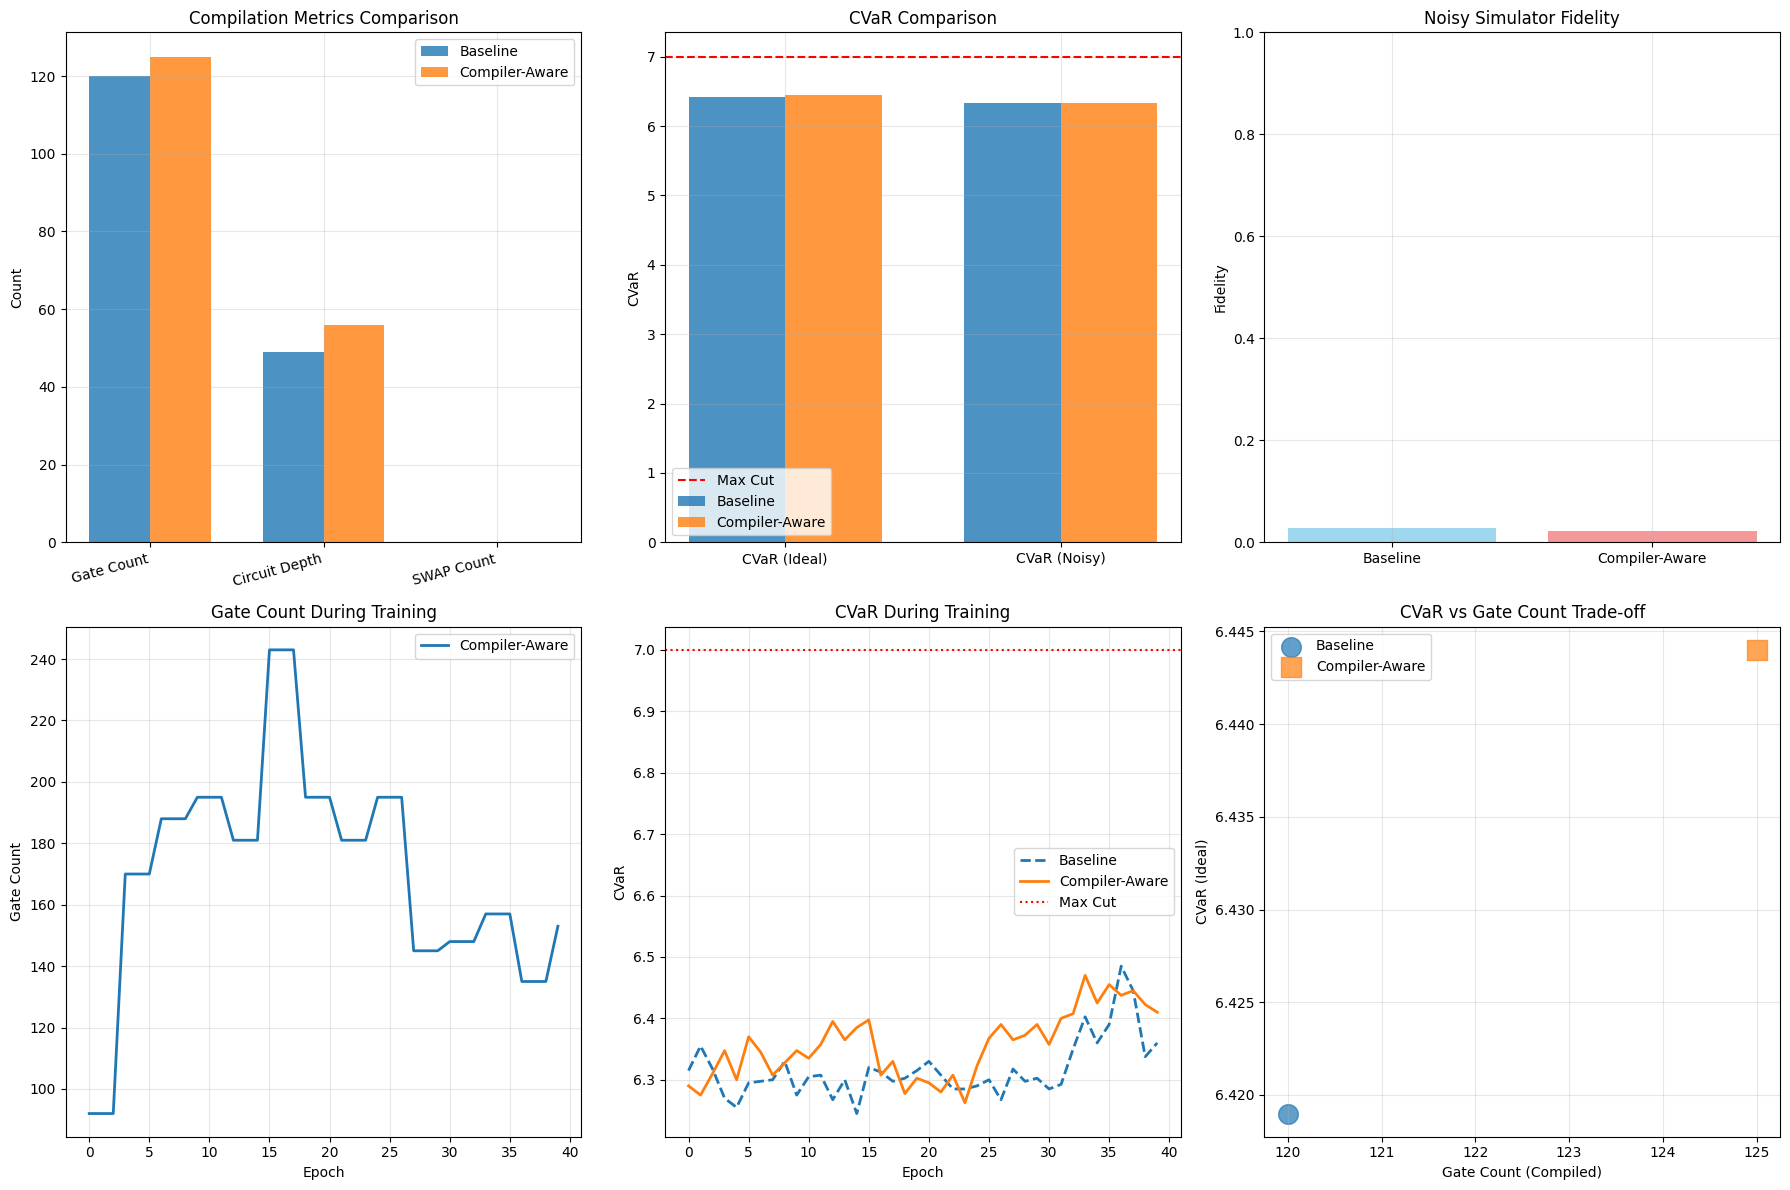


COMPARISON SUMMARY

Metric                         Baseline             Compiler-Aware       Improvement         
------------------------------------------------------------------------------------------
Gate Count                     120                  125                  -5.0
Circuit Depth                  49                   56                   -7.0
SWAP Count (optimized)         0                    0                    0.0
CVaR (Ideal)                   6.42                 6.44                 0.02
CVaR (Noisy)                   6.33                 6.33                 0.00
Fidelity (Noisy)               0.0290               0.0218               -0.0072
Expected Error Rate            0.0512               0.0551               -0.0039


In [ ]:
# Example 1: 6-node graph comparison with p_edge = 0.5
print("=" * 60)
print("Compiler-Aware QuantumDARTS: 6-Node Graph")
print("=" * 60)

# Generate graph
graph_6 = generate_erdos_renyi_graph(n_nodes=6, p_edge=0.5, seed=42)
max_cut_6, _ = compute_max_cut_classical(graph_6)
print(f"Graph: 6 nodes, {len(graph_6.edges())} edges, Max-Cut = {max_cut_6}")

# Get coupling map from existing backend
try:
    if 'backend' in globals():
        coupling_map_6 = get_ibm_torino_coupling_map(backend=backend)
        print(f"Using coupling map from backend: {backend.name if backend else 'None'}")
    else:
        coupling_map_6 = None
        print("No backend available, using all-to-all coupling map")
except Exception as e:
    print(f"Warning: Could not get coupling map: {e}")
    coupling_map_6 = None

# Train baseline model
print("\n" + "-" * 60)
print("Training Baseline Micro-Search Model")
print("-" * 60)
baseline_6 = MicroSearchMaxCut(
    n_qubits=6,
    graph=graph_6,
    sub_layers=3,
    K_prime=16,
    tau_init=6.0,
    lr_theta=0.02,
    lr_alpha=0.02,
    num_iter=10,
    sampler_decay=0.985,
    tau_min=0.8,
)
baseline_6.train(num_epochs=40, verbose=True)

# Get baseline model's final gate count for normalization
print("\nGetting baseline model's final gate count...")
baseline_qc_6 = build_qiskit_circuit(baseline_6)
backend_6 = None
try:
    if 'backend' in globals():
        backend_6 = globals()['backend']
except:
    pass
baseline_compiled_6 = compile_circuit_metrics(baseline_qc_6, coupling_map_6, backend=backend_6, optimization_level=1)
baseline_gates_6 = baseline_compiled_6['gate_count']
print(f"Baseline model final gate count: {baseline_gates_6}")

# Train compiler-aware model
print("\n" + "-" * 60)
print("Training Compiler-Aware Micro-Search Model")
print("-" * 60)
# Get backend for compiler-aware model
if backend_6 is None:
    try:
        if 'backend' in globals():
            print("Using backend from globals")
            backend_6 = globals()['backend']
    except:
        pass

compiler_aware_6 = CompilerAwareMicroSearchMaxCut(
    n_qubits=6,
    graph=graph_6,
    sub_layers=3,
    K_prime=16,
    tau_init=6.0,
    lr_theta=0.02,
    lr_alpha=0.02,
    num_iter=10,
    sampler_decay=0.985,
    tau_min=0.8,
    loss_weights=(2.0, 3.0, 1.0),  # SIGNIFICANTLY increased (10x) for real effect
    coupling_map=coupling_map_6,
    compile_every_n_epochs=3,  # Compile more frequently for better guidance
    backend=backend_6,  # Pass backend explicitly
    baseline_gates=baseline_gates_6,  # Use baseline model's gate count
)
compiler_aware_6.train(num_epochs=40, verbose=True)

# Compare results
print("\n" + "=" * 60)
print("COMPARISON: Baseline vs Compiler-Aware (6-node)")
print("=" * 60)
comparison_6 = compare_baseline_vs_compiler_aware(baseline_6, compiler_aware_6, graph_6)



Compiler-Aware QuantumDARTS: 6-Node Graph
Graph: 6 nodes, 7 edges, Max-Cut = 6
Using coupling map from backend: ibm_torino

------------------------------------------------------------
Training Baseline Micro-Search Model
------------------------------------------------------------
Gate set G = {RzRyRz, I, CNOT} initialized with 4 candidate gates for 2 qubits
Epoch 0: L_theta=-3.4683, L_alpha=-3.4836, CVaR=5.16, tau=5.910
Epoch 10: L_theta=-3.5078, L_alpha=-3.5077, CVaR=5.22, tau=5.081
Epoch 20: L_theta=-3.5112, L_alpha=-3.5102, CVaR=5.20, tau=4.368
Epoch 30: L_theta=-3.5237, L_alpha=-3.5227, CVaR=5.10, tau=3.756
Epoch 39: L_theta=-3.5527, L_alpha=-3.5561, CVaR=5.22, tau=3.278
Micro-search training complete.

Getting baseline model's final gate count...
Baseline model final gate count: 103

------------------------------------------------------------
Training Compiler-Aware Micro-Search Model
------------------------------------------------------------
Gate set G = {RzRyRz, I, CNOT} in

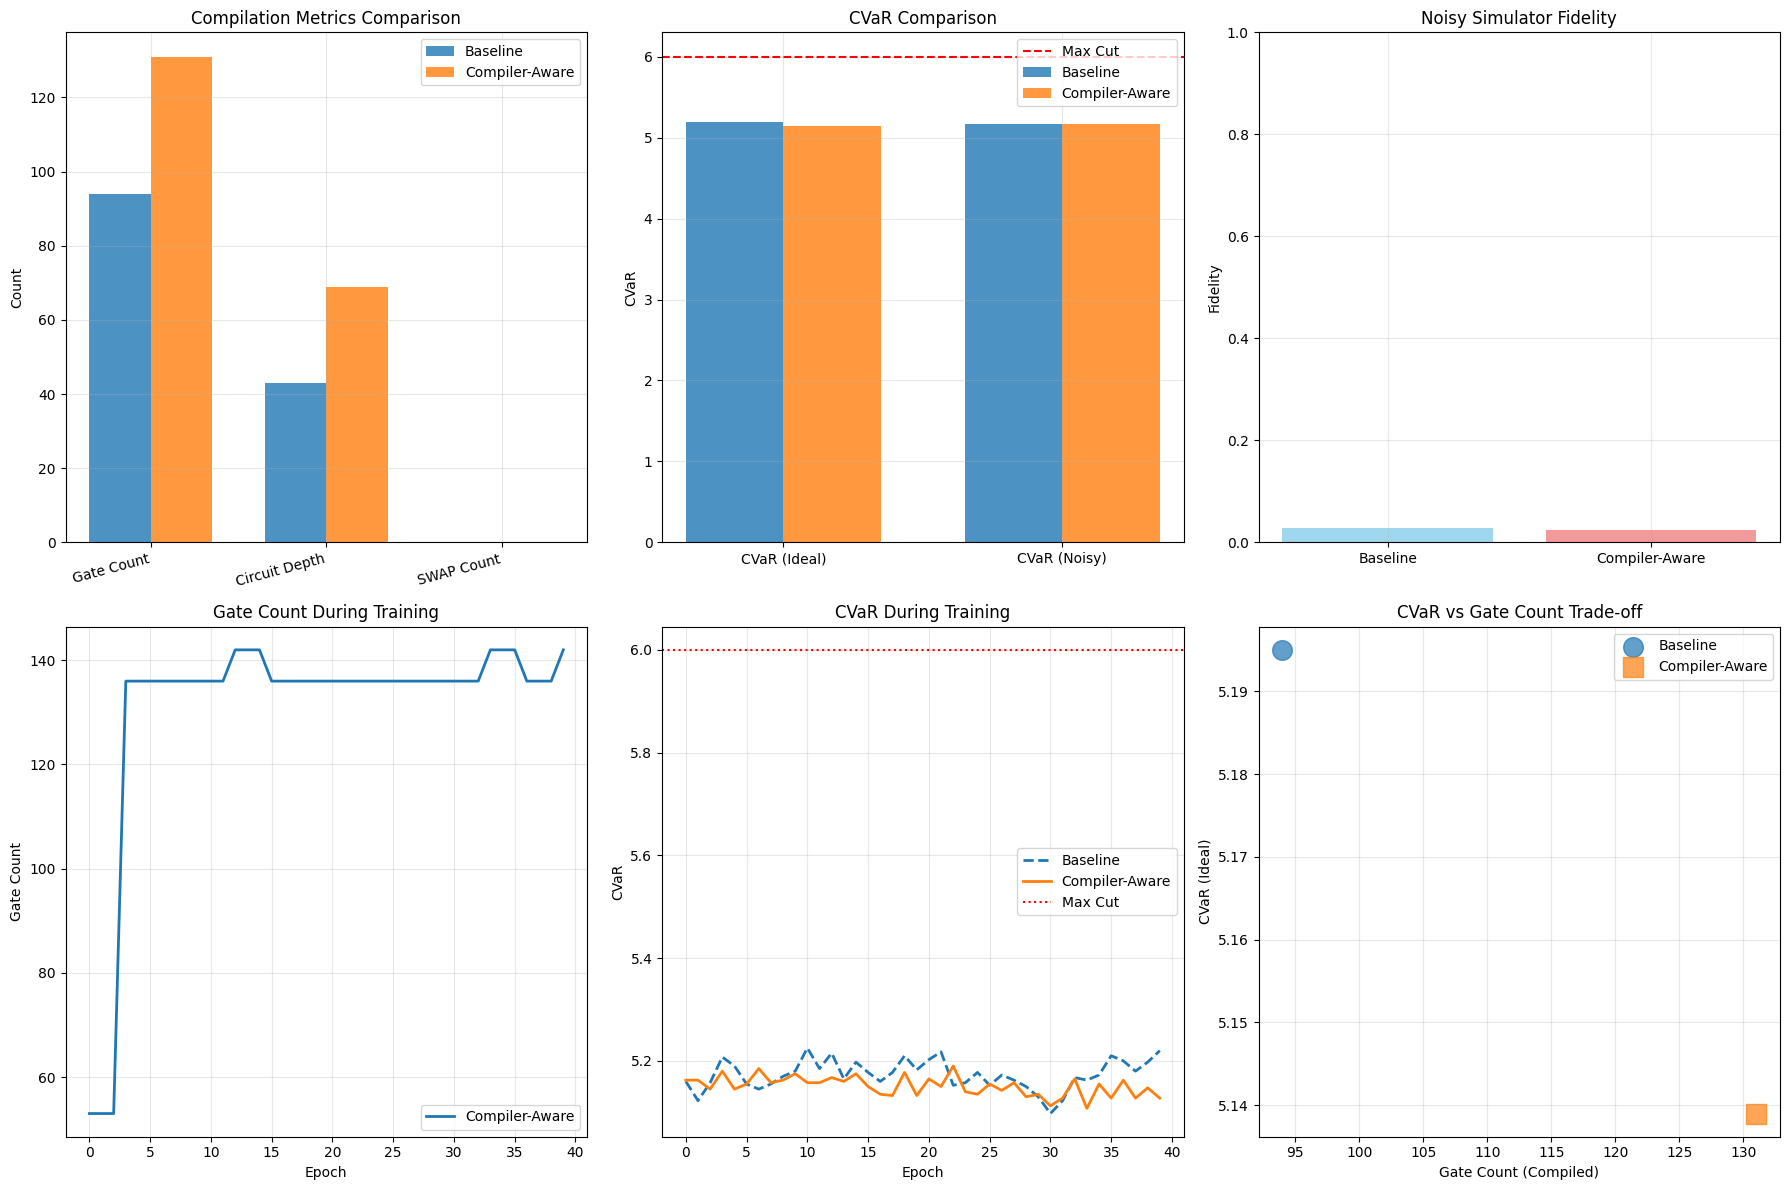


COMPARISON SUMMARY

Metric                         Baseline             Compiler-Aware       Improvement         
------------------------------------------------------------------------------------------
Gate Count                     94                   131                  -37.0
Circuit Depth                  43                   69                   -26.0
SWAP Count (optimized)         0                    0                    0.0
CVaR (Ideal)                   5.20                 5.14                 -0.06
CVaR (Noisy)                   5.17                 5.17                 0.00
Fidelity (Noisy)               0.0278               0.0248               -0.0030
Expected Error Rate            0.0349               0.0553               -0.0204


In [65]:
# Example 1: 6-node graph comparison with p_edge = 0.25
print("=" * 60)
print("Compiler-Aware QuantumDARTS: 6-Node Graph")
print("=" * 60)

# Generate graph
graph_6 = generate_erdos_renyi_graph(n_nodes=6, p_edge=0.25, seed=42)
max_cut_6, _ = compute_max_cut_classical(graph_6)
print(f"Graph: 6 nodes, {len(graph_6.edges())} edges, Max-Cut = {max_cut_6}")

# Get coupling map from existing backend
try:
    if 'backend' in globals():
        coupling_map_6 = get_ibm_torino_coupling_map(backend=backend)
        print(f"Using coupling map from backend: {backend.name if backend else 'None'}")
    else:
        coupling_map_6 = None
        print("No backend available, using all-to-all coupling map")
except Exception as e:
    print(f"Warning: Could not get coupling map: {e}")
    coupling_map_6 = None

# Train baseline model
print("\n" + "-" * 60)
print("Training Baseline Micro-Search Model")
print("-" * 60)
baseline_6 = MicroSearchMaxCut(
    n_qubits=6,
    graph=graph_6,
    sub_layers=3,
    K_prime=16,
    tau_init=6.0,
    lr_theta=0.02,
    lr_alpha=0.02,
    num_iter=10,
    sampler_decay=0.985,
    tau_min=0.8,
)
baseline_6.train(num_epochs=40, verbose=True)

# Get baseline model's final gate count for normalization
print("\nGetting baseline model's final gate count...")
baseline_qc_6 = build_qiskit_circuit(baseline_6)
backend_6 = None
try:
    if 'backend' in globals():
        backend_6 = globals()['backend']
except:
    pass
baseline_compiled_6 = compile_circuit_metrics(baseline_qc_6, coupling_map_6, backend=backend_6, optimization_level=1)
baseline_gates_6 = baseline_compiled_6['gate_count']
print(f"Baseline model final gate count: {baseline_gates_6}")

# Train compiler-aware model
print("\n" + "-" * 60)
print("Training Compiler-Aware Micro-Search Model")
print("-" * 60)
# Get backend for compiler-aware model
if backend_6 is None:
    try:
        if 'backend' in globals():
            print("Using backend from globals")
            backend_6 = globals()['backend']
    except:
        pass

compiler_aware_6 = CompilerAwareMicroSearchMaxCut(
    n_qubits=6,
    graph=graph_6,
    sub_layers=3,
    K_prime=16,
    tau_init=6.0,
    lr_theta=0.02,
    lr_alpha=0.02,
    num_iter=10,
    sampler_decay=0.985,
    tau_min=0.8,
    loss_weights=(2.0, 3.0, 1.0),  # SIGNIFICANTLY increased (10x) for real effect
    coupling_map=coupling_map_6,
    compile_every_n_epochs=3,  # Compile more frequently for better guidance
    backend=backend_6,  # Pass backend explicitly
    baseline_gates=baseline_gates_6,  # Use baseline model's gate count
)
compiler_aware_6.train(num_epochs=40, verbose=True)

# Compare results
print("\n" + "=" * 60)
print("COMPARISON: Baseline vs Compiler-Aware (6-node)")
print("=" * 60)
comparison_6 = compare_baseline_vs_compiler_aware(baseline_6, compiler_aware_6, graph_6)



Compiler-Aware QuantumDARTS: 6-Node Graph
Graph: 6 nodes, 14 edges, Max-Cut = 9
Using coupling map from backend: ibm_torino

------------------------------------------------------------
Training Baseline Micro-Search Model
------------------------------------------------------------
Gate set G = {RzRyRz, I, CNOT} initialized with 4 candidate gates for 2 qubits
Epoch 0: L_theta=-6.8864, L_alpha=-6.9822, CVaR=8.66, tau=5.910
Epoch 10: L_theta=-7.0280, L_alpha=-7.0284, CVaR=8.66, tau=5.081
Epoch 20: L_theta=-7.0314, L_alpha=-7.0311, CVaR=8.68, tau=4.368
Epoch 30: L_theta=-7.0446, L_alpha=-7.0481, CVaR=8.60, tau=3.756
Epoch 39: L_theta=-7.0934, L_alpha=-7.1018, CVaR=8.65, tau=3.278
Micro-search training complete.

Getting baseline model's final gate count...
Baseline model final gate count: 305

------------------------------------------------------------
Training Compiler-Aware Micro-Search Model
------------------------------------------------------------
Gate set G = {RzRyRz, I, CNOT} i

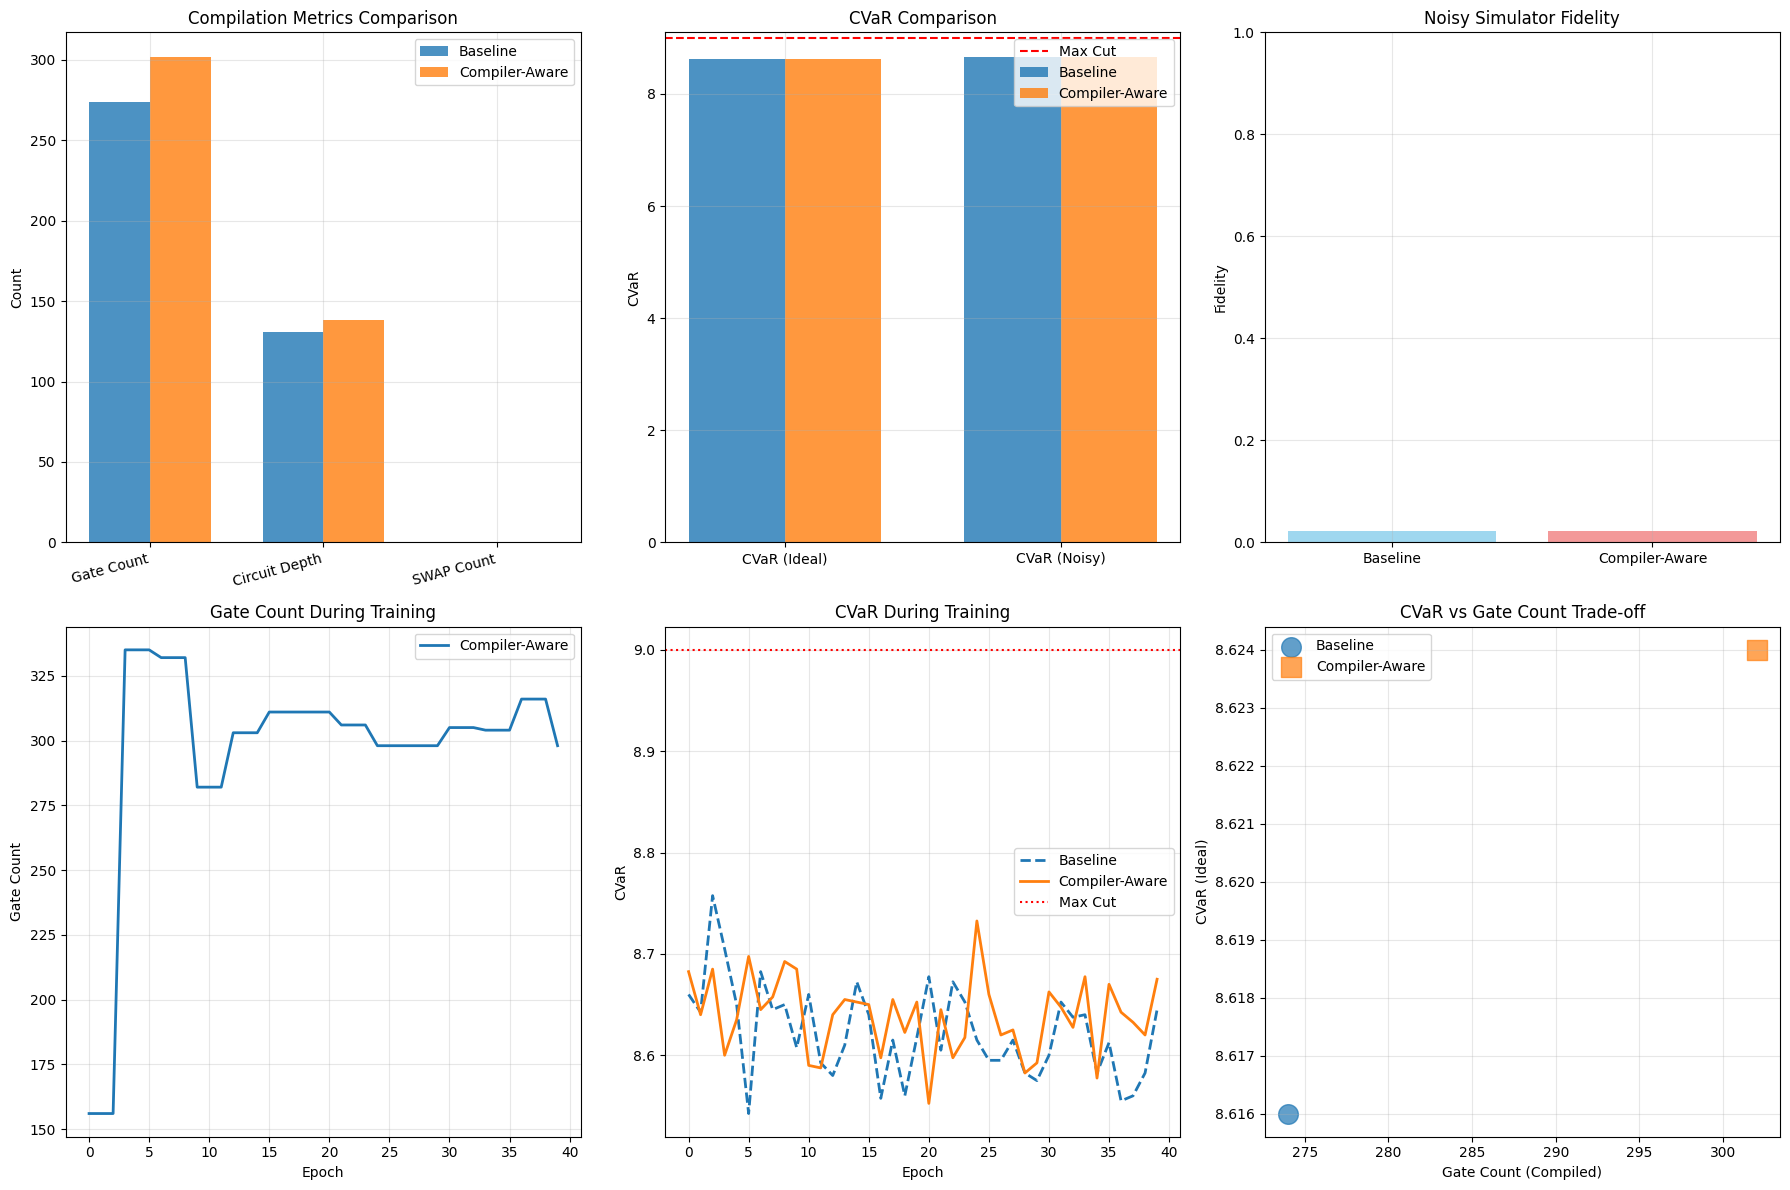


COMPARISON SUMMARY

Metric                         Baseline             Compiler-Aware       Improvement         
------------------------------------------------------------------------------------------
Gate Count                     274                  302                  -28.0
Circuit Depth                  131                  138                  -7.0
SWAP Count (optimized)         0                    0                    0.0
CVaR (Ideal)                   8.62                 8.62                 0.01
CVaR (Noisy)                   8.67                 8.67                 0.00
Fidelity (Noisy)               0.0224               0.0214               -0.0010
Expected Error Rate            0.1421               0.1585               -0.0164


In [66]:
# Example 1: 6-node graph comparison with p_edge = 0.75
print("=" * 60)
print("Compiler-Aware QuantumDARTS: 6-Node Graph")
print("=" * 60)

# Generate graph
graph_6 = generate_erdos_renyi_graph(n_nodes=6, p_edge=0.75, seed=42)
max_cut_6, _ = compute_max_cut_classical(graph_6)
print(f"Graph: 6 nodes, {len(graph_6.edges())} edges, Max-Cut = {max_cut_6}")

# Get coupling map from existing backend
try:
    if 'backend' in globals():
        coupling_map_6 = get_ibm_torino_coupling_map(backend=backend)
        print(f"Using coupling map from backend: {backend.name if backend else 'None'}")
    else:
        coupling_map_6 = None
        print("No backend available, using all-to-all coupling map")
except Exception as e:
    print(f"Warning: Could not get coupling map: {e}")
    coupling_map_6 = None

# Train baseline model
print("\n" + "-" * 60)
print("Training Baseline Micro-Search Model")
print("-" * 60)
baseline_6 = MicroSearchMaxCut(
    n_qubits=6,
    graph=graph_6,
    sub_layers=3,
    K_prime=16,
    tau_init=6.0,
    lr_theta=0.02,
    lr_alpha=0.02,
    num_iter=10,
    sampler_decay=0.985,
    tau_min=0.8,
)
baseline_6.train(num_epochs=40, verbose=True)

# Get baseline model's final gate count for normalization
print("\nGetting baseline model's final gate count...")
baseline_qc_6 = build_qiskit_circuit(baseline_6)
backend_6 = None
try:
    if 'backend' in globals():
        backend_6 = globals()['backend']
except:
    pass
baseline_compiled_6 = compile_circuit_metrics(baseline_qc_6, coupling_map_6, backend=backend_6, optimization_level=1)
baseline_gates_6 = baseline_compiled_6['gate_count']
print(f"Baseline model final gate count: {baseline_gates_6}")

# Train compiler-aware model
print("\n" + "-" * 60)
print("Training Compiler-Aware Micro-Search Model")
print("-" * 60)
# Get backend for compiler-aware model
if backend_6 is None:
    try:
        if 'backend' in globals():
            print("Using backend from globals")
            backend_6 = globals()['backend']
    except:
        pass

compiler_aware_6 = CompilerAwareMicroSearchMaxCut(
    n_qubits=6,
    graph=graph_6,
    sub_layers=3,
    K_prime=16,
    tau_init=6.0,
    lr_theta=0.02,
    lr_alpha=0.02,
    num_iter=10,
    sampler_decay=0.985,
    tau_min=0.8,
    loss_weights=(2.0, 3.0, 1.0),  # SIGNIFICANTLY increased (10x) for real effect
    coupling_map=coupling_map_6,
    compile_every_n_epochs=3,  # Compile more frequently for better guidance
    backend=backend_6,  # Pass backend explicitly,
    baseline_gates=baseline_gates_6,  # Use baseline model's gate count
)
compiler_aware_6.train(num_epochs=40, verbose=True)

# Compare results
print("\n" + "=" * 60)
print("COMPARISON: Baseline vs Compiler-Aware (6-node)")
print("=" * 60)
comparison_6 = compare_baseline_vs_compiler_aware(baseline_6, compiler_aware_6, graph_6)



### Example 2: 8-Node Graph Comparison

Train both models on an 8-node graph for larger-scale comparison.



Compiler-Aware QuantumDARTS: 8-Node Graph
Graph: 8 nodes, 16 edges, Max-Cut = 13
Using coupling map from backend: ibm_torino

------------------------------------------------------------
Training Baseline Micro-Search Model
------------------------------------------------------------
Gate set G = {RzRyRz, I, CNOT} initialized with 4 candidate gates for 2 qubits
Epoch 0: L_theta=-7.3490, L_alpha=-7.7820, CVaR=10.55, tau=5.910
Epoch 10: L_theta=-8.0094, L_alpha=-8.0099, CVaR=10.53, tau=5.081
Epoch 20: L_theta=-8.0094, L_alpha=-8.0090, CVaR=10.67, tau=4.368
Epoch 29: L_theta=-8.0104, L_alpha=-8.0097, CVaR=10.53, tau=3.813
Micro-search training complete.

Getting baseline model's final gate count...
Baseline model final gate count: 333

------------------------------------------------------------
Training Compiler-Aware Micro-Search Model
------------------------------------------------------------
Gate set G = {RzRyRz, I, CNOT} initialized with 4 candidate gates for 2 qubits
Epoch 0: L_th

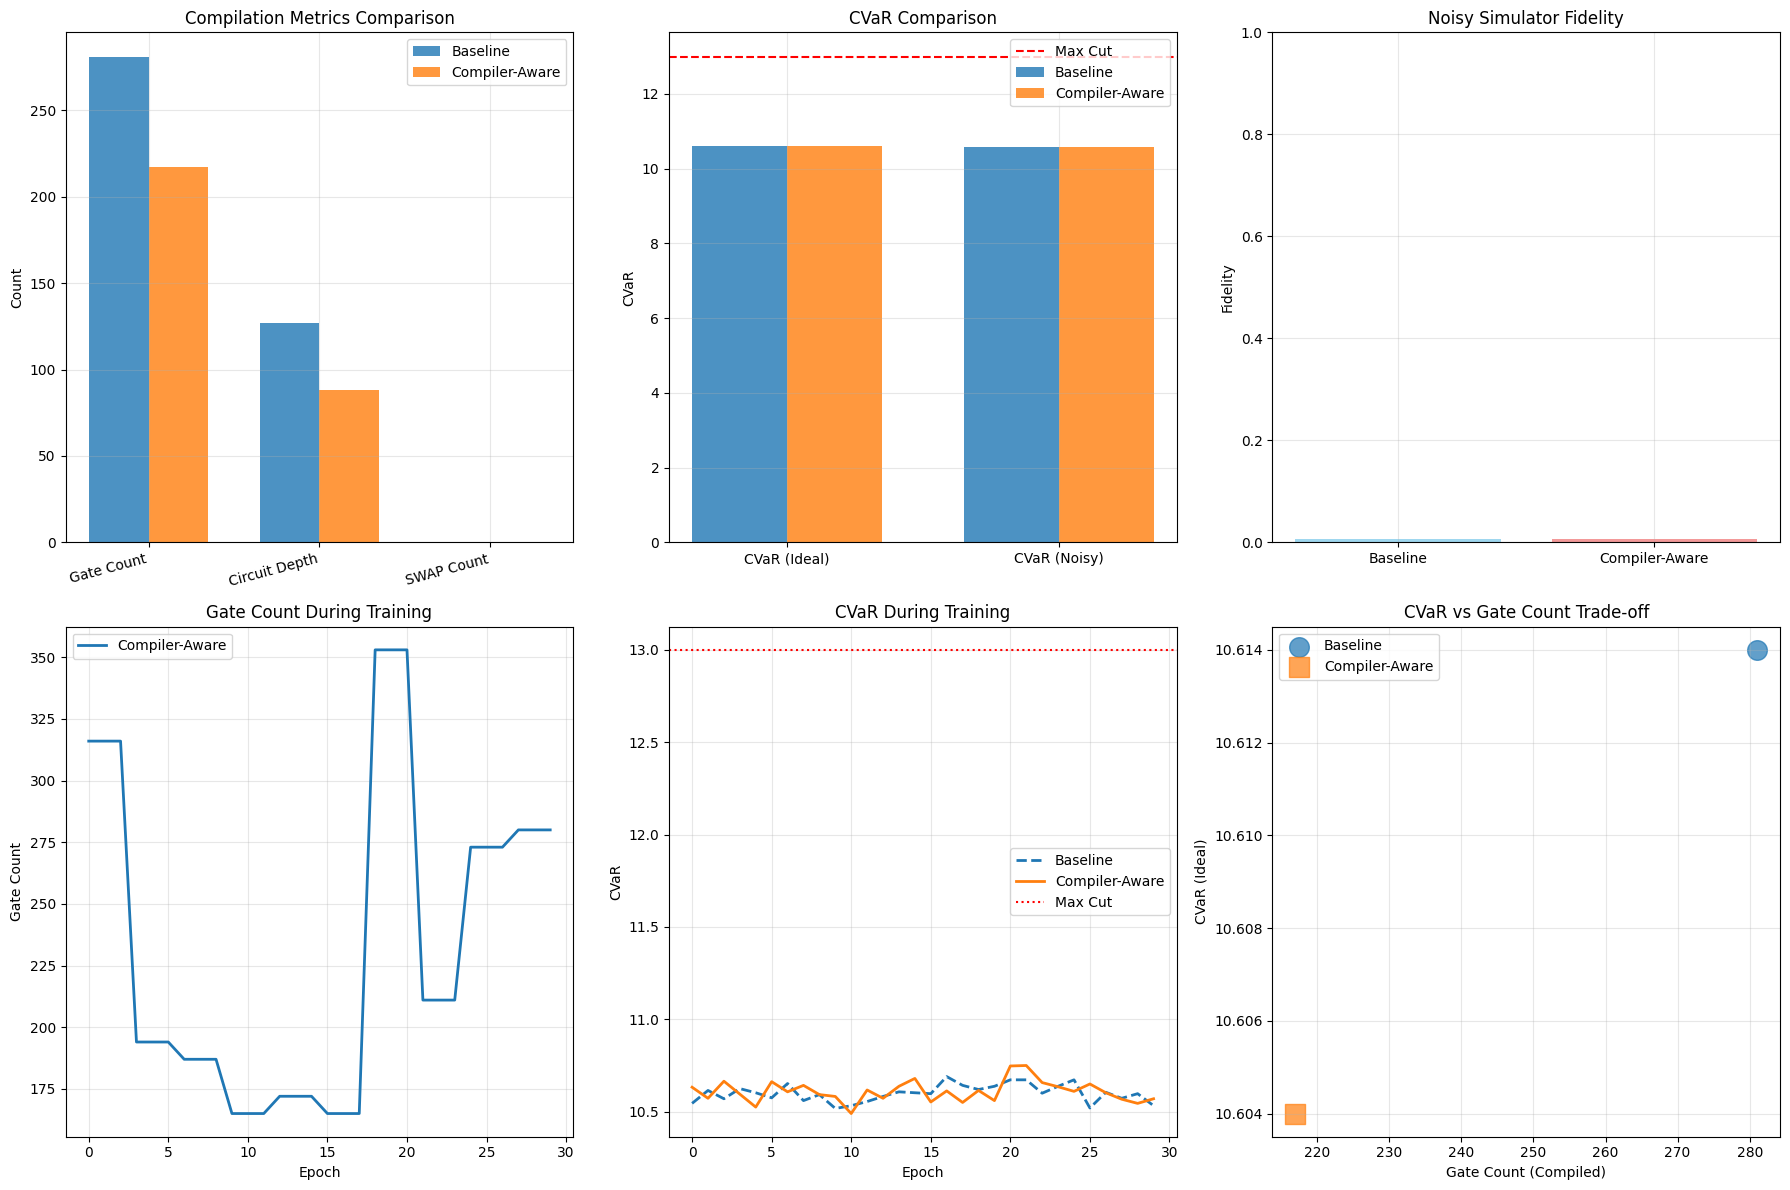


COMPARISON SUMMARY

Metric                         Baseline             Compiler-Aware       Improvement         
------------------------------------------------------------------------------------------
Gate Count                     281                  217                  64.0
Circuit Depth                  127                  88                   39.0
SWAP Count (optimized)         0                    0                    0.0
CVaR (Ideal)                   10.61                10.60                -0.01
CVaR (Noisy)                   10.59                10.59                0.00
Fidelity (Noisy)               0.0068               0.0066               -0.0002
Expected Error Rate            0.1566               0.0924               0.0642


In [ ]:
# Example 2: 8-node graph comparison with p_edge = 0.5
print("=" * 60)
print("Compiler-Aware QuantumDARTS: 8-Node Graph")
print("=" * 60)

# Generate graph
graph_8 = generate_erdos_renyi_graph(n_nodes=8, p_edge=0.5, seed=42)
max_cut_8, _ = compute_max_cut_classical(graph_8)
print(f"Graph: 8 nodes, {len(graph_8.edges())} edges, Max-Cut = {max_cut_8}")

# Get coupling map from existing backend
try:
    if 'backend' in globals():
        coupling_map_8 = get_ibm_torino_coupling_map(backend=backend)
        print(f"Using coupling map from backend: {backend.name if backend else 'None'}")
    else:
        coupling_map_8 = None
        print("No backend available, using all-to-all coupling map")
except Exception as e:
    print(f"Warning: Could not get coupling map: {e}")
    coupling_map_8 = None

# Train baseline model
print("\n" + "-" * 60)
print("Training Baseline Micro-Search Model")
print("-" * 60)
baseline_8 = MicroSearchMaxCut(
    n_qubits=8,
    graph=graph_8,
    sub_layers=3,
    K_prime=16,
    tau_init=6.0,
    lr_theta=0.02,
    lr_alpha=0.02,
    num_iter=8,  # Fewer iterations for speed
    sampler_decay=0.985,
    tau_min=0.8,
)
baseline_8.train(num_epochs=30, verbose=True)  # Fewer epochs for speed

# Get baseline model's final gate count for normalization
print("\nGetting baseline model's final gate count...")
baseline_qc_8 = build_qiskit_circuit(baseline_8)
baseline_compiled_8 = compile_circuit_metrics(baseline_qc_8, coupling_map_8, backend=backend_8, optimization_level=1)
baseline_gates_8 = baseline_compiled_8['gate_count']
print(f"Baseline model final gate count: {baseline_gates_8}")

# Train compiler-aware model
print("\n" + "-" * 60)
print("Training Compiler-Aware Micro-Search Model")
print("-" * 60)
# Get backend for compiler-aware model
backend_8 = None
try:
    if 'backend' in globals():
        backend_8 = globals()['backend']
except:
    pass

compiler_aware_8 = CompilerAwareMicroSearchMaxCut(
    n_qubits=8,
    graph=graph_8,
    sub_layers=3,
    K_prime=16,
    tau_init=6.0,
    lr_theta=0.02,
    lr_alpha=0.02,
    num_iter=8,
    sampler_decay=0.985,
    tau_min=0.8,
    loss_weights=(2.0, 3.0, 1.0),  # SIGNIFICANTLY increased (10x) for real effect
    coupling_map=coupling_map_8,
    compile_every_n_epochs=3,  # More frequent compilation
    backend=backend_8,  # Pass backend explicitly
    baseline_gates=baseline_gates_8,  # Use baseline model's gate count
)
compiler_aware_8.train(num_epochs=30, verbose=True)

# Compare results
print("\n" + "=" * 60)
print("COMPARISON: Baseline vs Compiler-Aware (8-node)")
print("=" * 60)
comparison_8 = compare_baseline_vs_compiler_aware(baseline_8, compiler_aware_8, graph_8)



Compiler-Aware QuantumDARTS: 8-Node Graph
Graph: 8 nodes, 12 edges, Max-Cut = 11
Using coupling map from backend: ibm_torino

------------------------------------------------------------
Training Baseline Micro-Search Model
------------------------------------------------------------
Gate set G = {RzRyRz, I, CNOT} initialized with 4 candidate gates for 2 qubits
Epoch 0: L_theta=-5.7715, L_alpha=-5.9346, CVaR=8.39, tau=5.910
Epoch 10: L_theta=-6.0038, L_alpha=-6.0044, CVaR=8.27, tau=5.081
Epoch 20: L_theta=-6.0040, L_alpha=-6.0039, CVaR=8.36, tau=4.368
Epoch 29: L_theta=-6.0056, L_alpha=-6.0046, CVaR=8.26, tau=3.813
Micro-search training complete.

Getting baseline model's final gate count...
Baseline model final gate count: 373

------------------------------------------------------------
Training Compiler-Aware Micro-Search Model
------------------------------------------------------------
Gate set G = {RzRyRz, I, CNOT} initialized with 4 candidate gates for 2 qubits
Epoch 0: L_theta=

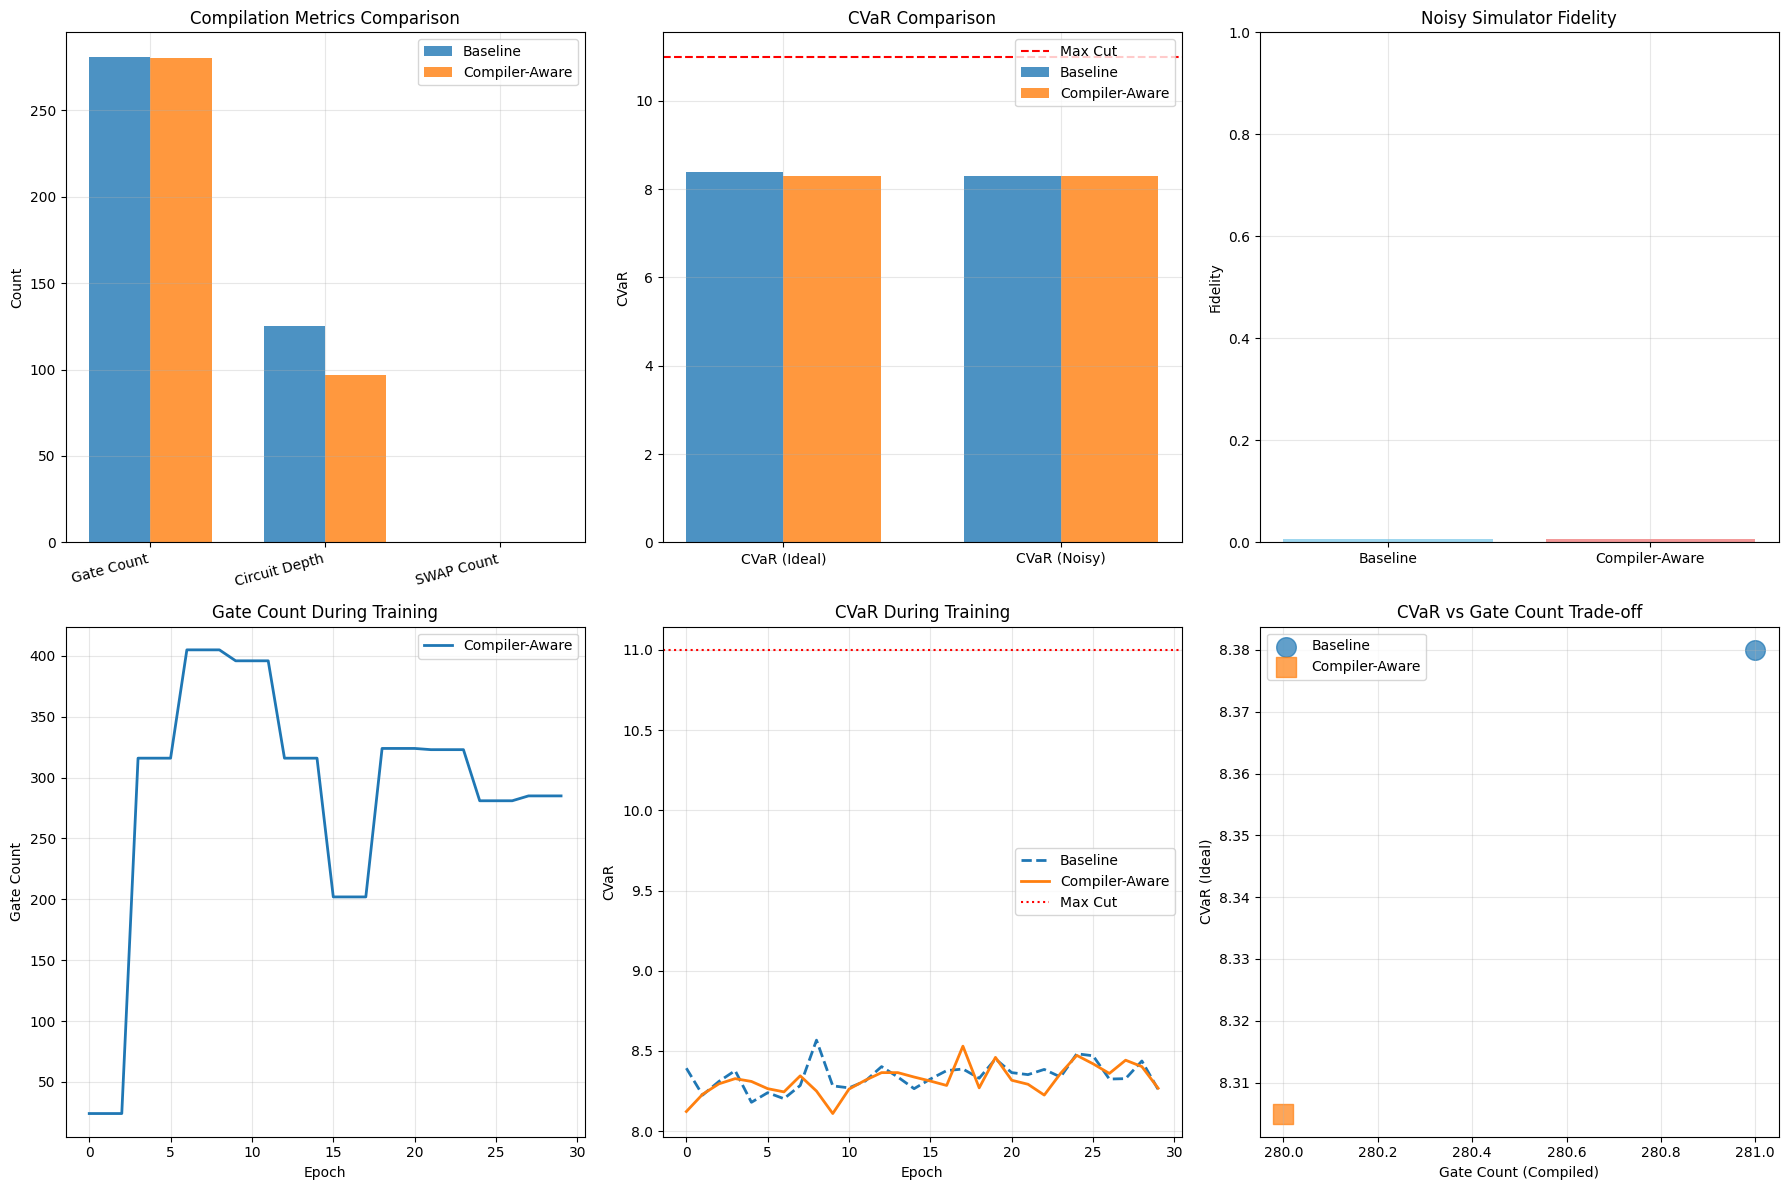


COMPARISON SUMMARY

Metric                         Baseline             Compiler-Aware       Improvement         
------------------------------------------------------------------------------------------
Gate Count                     281                  280                  1.0
Circuit Depth                  125                  97                   28.0
SWAP Count (optimized)         0                    0                    0.0
CVaR (Ideal)                   8.38                 8.31                 -0.07
CVaR (Noisy)                   8.29                 8.29                 0.00
Fidelity (Noisy)               0.0070               0.0070               0.0000
Expected Error Rate            0.1346               0.1319               0.0027


In [67]:
# Example 2: 8-node graph comparison with p_edge = 0.25
print("=" * 60)
print("Compiler-Aware QuantumDARTS: 8-Node Graph")
print("=" * 60)

# Generate graph
graph_8 = generate_erdos_renyi_graph(n_nodes=8, p_edge=0.25, seed=42)
max_cut_8, _ = compute_max_cut_classical(graph_8)
print(f"Graph: 8 nodes, {len(graph_8.edges())} edges, Max-Cut = {max_cut_8}")

# Get coupling map from existing backend
try:
    if 'backend' in globals():
        coupling_map_8 = get_ibm_torino_coupling_map(backend=backend)
        print(f"Using coupling map from backend: {backend.name if backend else 'None'}")
    else:
        coupling_map_8 = None
        print("No backend available, using all-to-all coupling map")
except Exception as e:
    print(f"Warning: Could not get coupling map: {e}")
    coupling_map_8 = None

# Train baseline model
print("\n" + "-" * 60)
print("Training Baseline Micro-Search Model")
print("-" * 60)
baseline_8 = MicroSearchMaxCut(
    n_qubits=8,
    graph=graph_8,
    sub_layers=3,
    K_prime=16,
    tau_init=6.0,
    lr_theta=0.02,
    lr_alpha=0.02,
    num_iter=8,  # Fewer iterations for speed
    sampler_decay=0.985,
    tau_min=0.8,
)
baseline_8.train(num_epochs=30, verbose=True)  # Fewer epochs for speed

# Get baseline model's final gate count for normalization
print("\nGetting baseline model's final gate count...")
baseline_qc_8 = build_qiskit_circuit(baseline_8)
baseline_compiled_8 = compile_circuit_metrics(baseline_qc_8, coupling_map_8, backend=backend_8, optimization_level=1)
baseline_gates_8 = baseline_compiled_8['gate_count']
print(f"Baseline model final gate count: {baseline_gates_8}")

# Train compiler-aware model
print("\n" + "-" * 60)
print("Training Compiler-Aware Micro-Search Model")
print("-" * 60)
# Get backend for compiler-aware model
backend_8 = None
try:
    if 'backend' in globals():
        backend_8 = globals()['backend']
except:
    pass

compiler_aware_8 = CompilerAwareMicroSearchMaxCut(
    n_qubits=8,
    graph=graph_8,
    sub_layers=3,
    K_prime=16,
    tau_init=6.0,
    lr_theta=0.02,
    lr_alpha=0.02,
    num_iter=8,
    sampler_decay=0.985,
    tau_min=0.8,
    loss_weights=(2.0, 3.0, 1.0),  # SIGNIFICANTLY increased (10x) for real effect
    coupling_map=coupling_map_8,
    compile_every_n_epochs=3,  # More frequent compilation
    backend=backend_8,  # Pass backend explicitly
    baseline_gates=baseline_gates_8,  # Use baseline model's gate count
)
compiler_aware_8.train(num_epochs=30, verbose=True)

# Compare results
print("\n" + "=" * 60)
print("COMPARISON: Baseline vs Compiler-Aware (8-node)")
print("=" * 60)
comparison_8 = compare_baseline_vs_compiler_aware(baseline_8, compiler_aware_8, graph_8)



Compiler-Aware QuantumDARTS: 8-Node Graph
Graph: 8 nodes, 24 edges, Max-Cut = 15
Using coupling map from backend: ibm_torino

------------------------------------------------------------
Training Baseline Micro-Search Model
------------------------------------------------------------
Gate set G = {RzRyRz, I, CNOT} initialized with 4 candidate gates for 2 qubits
Epoch 0: L_theta=-10.8165, L_alpha=-11.8666, CVaR=14.33, tau=5.910
Epoch 10: L_theta=-12.0195, L_alpha=-12.0196, CVaR=14.34, tau=5.081
Epoch 20: L_theta=-12.0198, L_alpha=-12.0196, CVaR=14.42, tau=4.368
Epoch 29: L_theta=-12.0201, L_alpha=-12.0190, CVaR=14.35, tau=3.813
Micro-search training complete.

Getting baseline model's final gate count...
Baseline model final gate count: 40

------------------------------------------------------------
Training Compiler-Aware Micro-Search Model
------------------------------------------------------------
Gate set G = {RzRyRz, I, CNOT} initialized with 4 candidate gates for 2 qubits
Epoch 

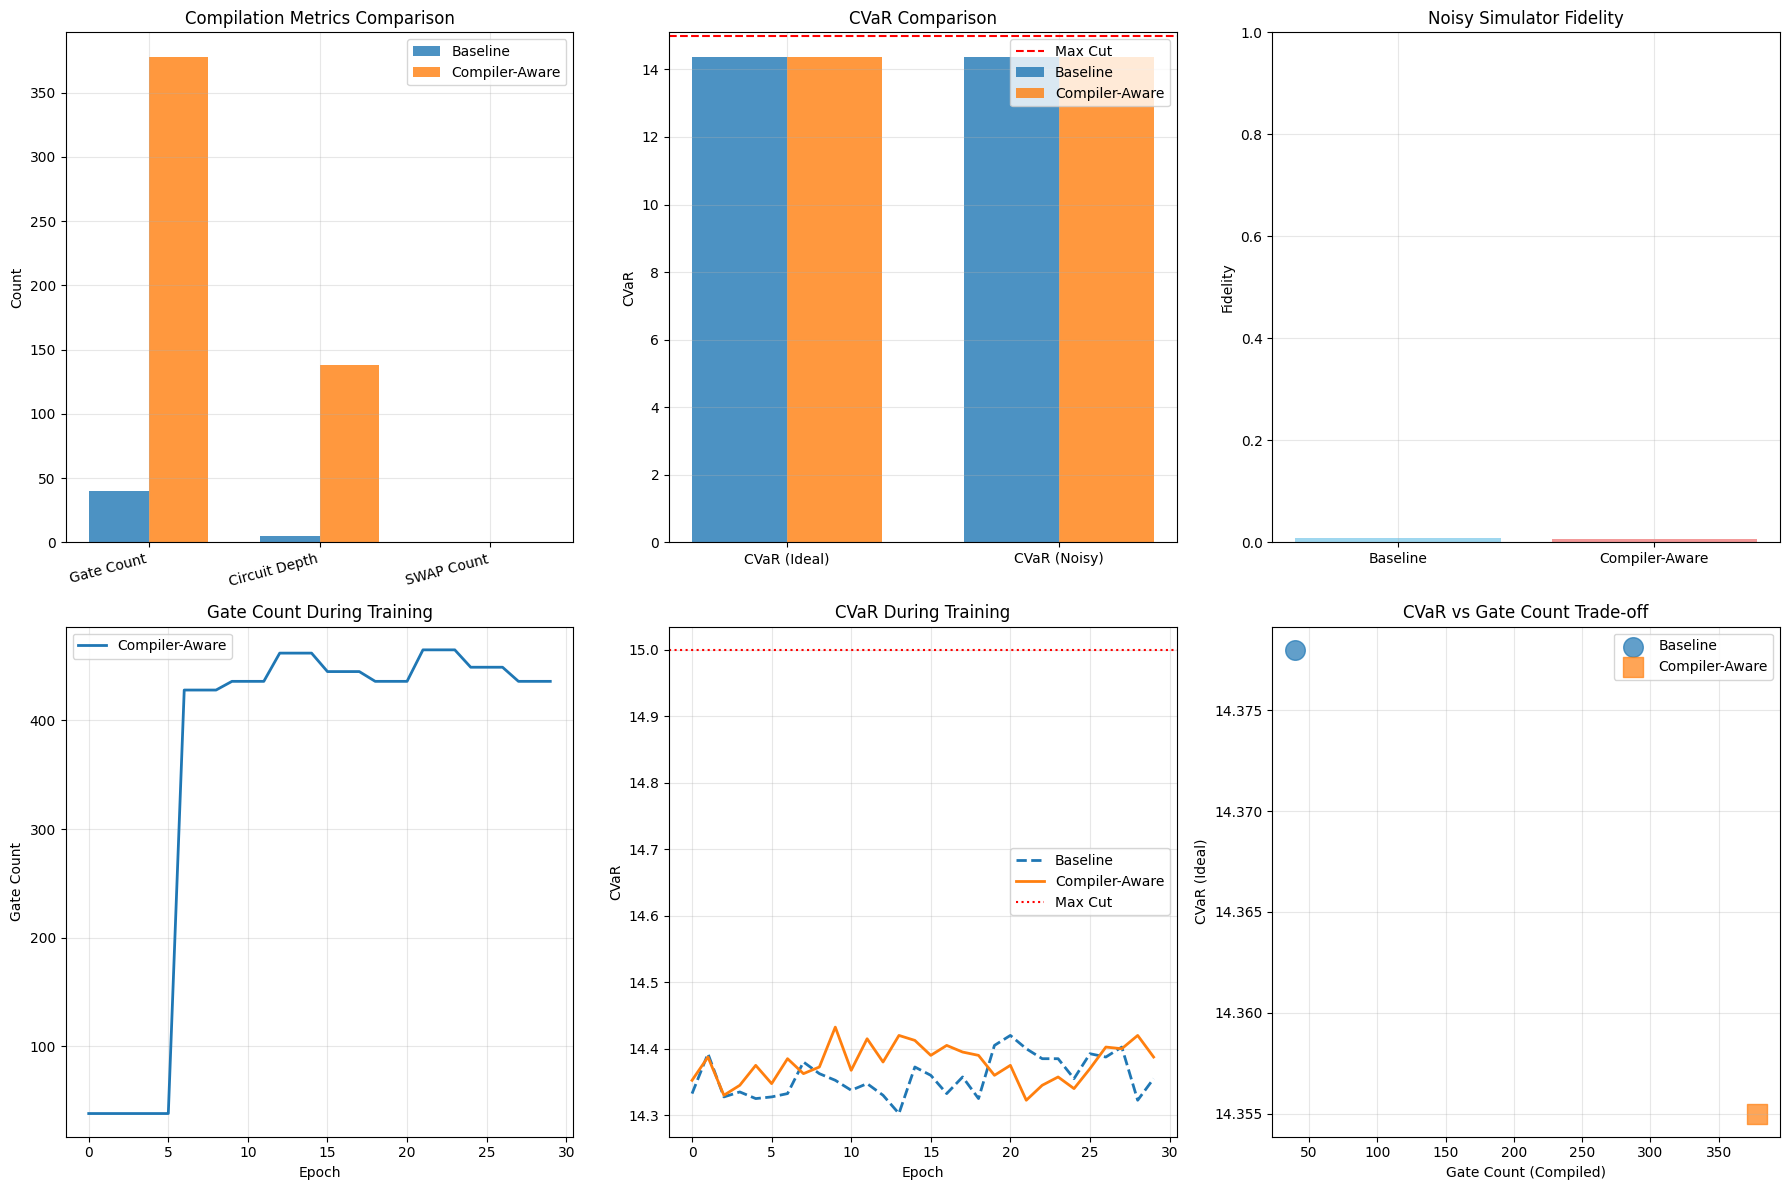


COMPARISON SUMMARY

Metric                         Baseline             Compiler-Aware       Improvement         
------------------------------------------------------------------------------------------
Gate Count                     40                   378                  -338.0
Circuit Depth                  5                    138                  -133.0
SWAP Count (optimized)         0                    0                    0.0
CVaR (Ideal)                   14.38                14.35                -0.02
CVaR (Noisy)                   14.35                14.35                0.00
Fidelity (Noisy)               0.0092               0.0068               -0.0024
Expected Error Rate            0.0039               0.2062               -0.2023


In [68]:
# Example 2: 8-node graph comparison with p_edge = 0.75
print("=" * 60)
print("Compiler-Aware QuantumDARTS: 8-Node Graph")
print("=" * 60)

# Generate graph
graph_8 = generate_erdos_renyi_graph(n_nodes=8, p_edge=0.75, seed=42)
max_cut_8, _ = compute_max_cut_classical(graph_8)
print(f"Graph: 8 nodes, {len(graph_8.edges())} edges, Max-Cut = {max_cut_8}")

# Get coupling map from existing backend
try:
    if 'backend' in globals():
        coupling_map_8 = get_ibm_torino_coupling_map(backend=backend)
        print(f"Using coupling map from backend: {backend.name if backend else 'None'}")
    else:
        coupling_map_8 = None
        print("No backend available, using all-to-all coupling map")
except Exception as e:
    print(f"Warning: Could not get coupling map: {e}")
    coupling_map_8 = None

# Train baseline model
print("\n" + "-" * 60)
print("Training Baseline Micro-Search Model")
print("-" * 60)
baseline_8 = MicroSearchMaxCut(
    n_qubits=8,
    graph=graph_8,
    sub_layers=3,
    K_prime=16,
    tau_init=6.0,
    lr_theta=0.02,
    lr_alpha=0.02,
    num_iter=8,  # Fewer iterations for speed
    sampler_decay=0.985,
    tau_min=0.8,
)
baseline_8.train(num_epochs=30, verbose=True)  # Fewer epochs for speed

# Get baseline model's final gate count for normalization
print("\nGetting baseline model's final gate count...")
baseline_qc_8 = build_qiskit_circuit(baseline_8)
baseline_compiled_8 = compile_circuit_metrics(baseline_qc_8, coupling_map_8, backend=backend_8, optimization_level=1)
baseline_gates_8 = baseline_compiled_8['gate_count']
print(f"Baseline model final gate count: {baseline_gates_8}")

# Train compiler-aware model
print("\n" + "-" * 60)
print("Training Compiler-Aware Micro-Search Model")
print("-" * 60)
# Get backend for compiler-aware model
backend_8 = None
try:
    if 'backend' in globals():
        backend_8 = globals()['backend']
except:
    pass

compiler_aware_8 = CompilerAwareMicroSearchMaxCut(
    n_qubits=8,
    graph=graph_8,
    sub_layers=3,
    K_prime=16,
    tau_init=6.0,
    lr_theta=0.02,
    lr_alpha=0.02,
    num_iter=8,
    sampler_decay=0.985,
    tau_min=0.8,
    loss_weights=(2.0, 3.0, 1.0),  # SIGNIFICANTLY increased (10x) for real effect
    coupling_map=coupling_map_8,
    compile_every_n_epochs=3,  # More frequent compilation
    backend=backend_8,  # Pass backend explicitly
    baseline_gates=baseline_gates_8,  # Use baseline model's gate count
)
compiler_aware_8.train(num_epochs=30, verbose=True)

# Compare results
print("\n" + "=" * 60)
print("COMPARISON: Baseline vs Compiler-Aware (8-node)")
print("=" * 60)
comparison_8 = compare_baseline_vs_compiler_aware(baseline_8, compiler_aware_8, graph_8)

